# OptiKuh EDA Notebook

This notebook mirrors the script workflow for VS Code/Jupyter. Run the full script for reproducible outputs; use these cells for interactive inspection.

## 1. Setup

In [15]:
from pathlib import Path
import sys
import importlib.util

import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start: Path = Path.cwd()) -> Path:
    """
    Finds the project root by looking for requirements.txt and data/.
    This makes the notebook work even if VS Code starts it from a different folder.
    """
    for path in [start, *start.parents]:
        if (path / "requirements.txt").exists() and (path / "data").exists():
            return path
    raise RuntimeError("Project root not found. Open VS Code from the Optikuh-Project folder.")

PROJECT_ROOT = find_project_root()
EDA_SCRIPT = PROJECT_ROOT / "src" / "eda" / "02_run_eda.py"

spec = importlib.util.spec_from_file_location("optikuh_eda", EDA_SCRIPT)

if spec is None or spec.loader is None:
    raise ImportError(f"Could not load EDA script from: {EDA_SCRIPT}")

eda = importlib.util.module_from_spec(spec)
spec.loader.exec_module(eda)
DATA_CSV = PROJECT_ROOT / "data" / "interim" / "optikuh.csv"
META_FILE = PROJECT_ROOT / "data" / "raw" / "optikuh_meta_variables.xlsx"

EDA_OUTPUTS = PROJECT_ROOT / "outputs" / "eda"
TABLES_DIR = EDA_OUTPUTS / "tables"
FIGURES_DIR = EDA_OUTPUTS / "figures"
REPORTS_DIR = EDA_OUTPUTS / "reports"

PRESENTATION_DIR = PROJECT_ROOT / "presentation"

print("Project root:", PROJECT_ROOT)
print("EDA script:", EDA_SCRIPT)
print("Data CSV:", DATA_CSV)

Project root: c:\Users\nixon\OneDrive\Desktop\Case Study\Optikuh-Project
EDA script: c:\Users\nixon\OneDrive\Desktop\Case Study\Optikuh-Project\src\eda\02_run_eda.py
Data CSV: c:\Users\nixon\OneDrive\Desktop\Case Study\Optikuh-Project\data\interim\optikuh.csv


## 2. Load data

In [3]:
df = eda.load_data(DATA_CSV)
meta = eda.load_meta(META_FILE)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (492540, 56)


,zeile,farm,lom,gebdat,alter,rasse,datum,kw,lnr,kaldat,...,gesundheit,abgdat,abggrund,gebdat_date,datum_date,kaldat_date,trodat_date,abgdat_date,health_status,episode_id
0,1,3,DE000113973296,38088,4057,1,42145,201521,8,41792.0,...,Produktionserkrankung/SonstigeErkrankung,NaN,NaN,2004-04-11,2015-05-21,2014-06-02,NaT,NaT,Production + other disease,DE000113973296_LN8_CALV41792.0
1,2,3,DE000113973296,38088,4058,1,42146,201521,8,41792.0,...,Produktionserkrankung/SonstigeErkrankung,NaN,NaN,2004-04-11,2015-05-22,2014-06-02,NaT,NaT,Production + other disease,DE000113973296_LN8_CALV41792.0
2,3,3,DE000113973296,38088,4059,1,42147,201521,8,41792.0,...,Produktionserkrankung/SonstigeErkrankung,NaN,NaN,2004-04-11,2015-05-23,2014-06-02,NaT,NaT,Production + other disease,DE000113973296_LN8_CALV41792.0
3,4,3,DE000113973296,38088,4060,1,42148,201521,8,41792.0,...,Produktionserkrankung/SonstigeErkrankung,NaN,NaN,2004-04-11,2015-05-24,2014-06-02,NaT,NaT,Production + other disease,DE000113973296_LN8_CALV41792.0
4,5,3,DE000113973296,38088,4061,1,42149,201522,8,41792.0,...,Produktionserkrankung/SonstigeErkrankung,NaN,NaN,2004-04-11,2015-05-25,2014-06-02,NaT,NaT,Production + other disease,DE000113973296_LN8_CALV41792.0


## 3. Dataset overview

In [5]:
tables = eda.make_tables(df, meta, TABLES_DIR)

overview = tables["overview"]
overview

,metric,value
0,rows_daily_records,492540
1,columns_original,49
2,columns_after_derived_dates,56
3,animals_unique_lom,1714
4,farms_unique,12
5,breed_codes_unique,4
6,lactation_episodes_approx,3086
7,observation_start,2014-08-28
8,observation_end,2017-03-23
9,daily_diagnosis_rows_any_disease,3889


## 4. Missingness

In [6]:
missingness = tables["missingness"]
missingness.head(20)

,variable,missing_count,missing_percent,non_missing_count
43,vo,492487,99.99,53
42,at,492515,99.99,25
45,so,492348,99.96,192
41,st,492117,99.91,423
44,pa,491978,99.89,562
38,eu,491935,99.88,605
40,fr,491701,99.83,839
39,kl,491256,99.74,1284
37,nsba,490109,99.51,2431
33,insulin,485505,98.57,7035


## 5. Health status tables

In [8]:
display(tables["health_rows"])
display(tables["health_episodes"])

,health_status,count,percent
0,Healthy,122636,24.90
1,Production disease,66080,13.42
2,Other disease,129159,26.22
3,Production + other disease,174665,35.46


,health_status,count,percent
0,Healthy,1234,39.97
1,Production disease,402,13.02
2,Other disease,721,23.36
3,Production + other disease,730,23.65


In [9]:
display(tables["farm_summary"])
display(tables["breed_summary"])

,farm,rows,animals,episodes,breed_codes,milk_records,bhb_records,rows_per_animal
0,1,124480,319,606,1,99869,1584,390.2
1,2,41082,220,412,1,33148,544,186.7
2,3,110622,355,593,1,105948,1058,311.6
3,4,47777,97,196,1,39680,625,492.5
4,5,37071,66,153,1,31422,481,561.7
5,6,7628,51,95,1,6535,288,149.6
6,7,20142,179,198,1,19999,640,112.5
7,8,35879,59,147,1,29853,483,608.1
8,9,25173,169,342,1,20106,891,149.0
9,10,13692,105,132,3,13540,140,130.4


,rasse,rows,animals,episodes,farms,row_percent
0,1,358121,1387,2458,8,72.71
1,2,403,2,3,1,0.08
2,4,5016,38,45,1,1.02
3,11,129000,287,580,4,26.19


## 6. Disease categories

In [10]:
display(tables["disease_category"])
display(tables["disease_diagnosis"].head(15))

,disease_column,category,daily_event_rows,unique_animals,unique_episodes,row_percent
1,kl,Claw/hoof (kl),1284,782,1000,0.261
2,fr,Reproduction (fr),839,587,658,0.170
0,eu,Udder (eu),605,501,581,0.123
6,pa,Parasitic (pa),562,446,554,0.114
3,st,Metabolic (st),423,313,353,0.086
7,so,Other (so),192,149,168,0.039
5,vo,Digestive (vo),53,53,53,0.011
4,at,Respiratory (at),25,24,24,0.005


,disease_column,category,diagnosis,daily_event_rows,unique_animals,unique_episodes
3,kl,Claw/hoof (kl),septische Erkrankung,700,567,695
0,eu,Udder (eu),Mastitis,578,497,577
17,pa,Parasitic (pa),Parasitose,562,446,554
4,kl,Claw/hoof (kl),aseptische Erkrankung,445,375,439
6,fr,Reproduction (fr),Zyklusstörung,379,346,379
7,fr,Reproduction (fr),Metritis,308,293,307
11,st,Metabolic (st),Hypocalcämie,212,191,212
12,st,Metabolic (st),Ketose,183,176,182
5,kl,Claw/hoof (kl),Sonstige Klauenerkrankungen,139,132,139
8,fr,Reproduction (fr),Nachgeburtsverhaltung,89,83,89


In [11]:
tables["biomarker_summary"].head(20)

,variable,health_status,count,mean,median,std,min,max
0,bhb,Healthy,2506,0.523,0.450,0.344,0.04,4.830
1,bhb,Production disease,885,0.602,0.490,0.474,0.12,4.760
2,bhb,Other disease,1775,0.575,0.490,0.453,0.02,9.460
3,bhb,Production + other disease,2051,0.695,0.540,0.590,0.03,5.950
4,glukose,Healthy,2508,3.502,3.550,0.502,0.41,5.520
5,glukose,Production disease,885,3.388,3.420,0.555,1.38,7.320
6,glukose,Other disease,1776,3.406,3.440,0.489,0.55,5.780
7,glukose,Production + other disease,2051,3.287,3.340,0.594,0.58,8.050
8,nefa,Healthy,2508,329.929,203.365,322.890,12.01,2772.340
9,nefa,Production disease,885,484.392,330.980,429.612,24.18,2654.560


## 7. Rebuild all tables and figures

In [12]:
eda.make_figures(df, tables, FIGURES_DIR)

print("Figures saved to:", FIGURES_DIR)

Figures saved to: c:\Users\nixon\OneDrive\Desktop\Case Study\Optikuh-Project\outputs\eda\figures


fig02_health_status_lactation_episodes.png


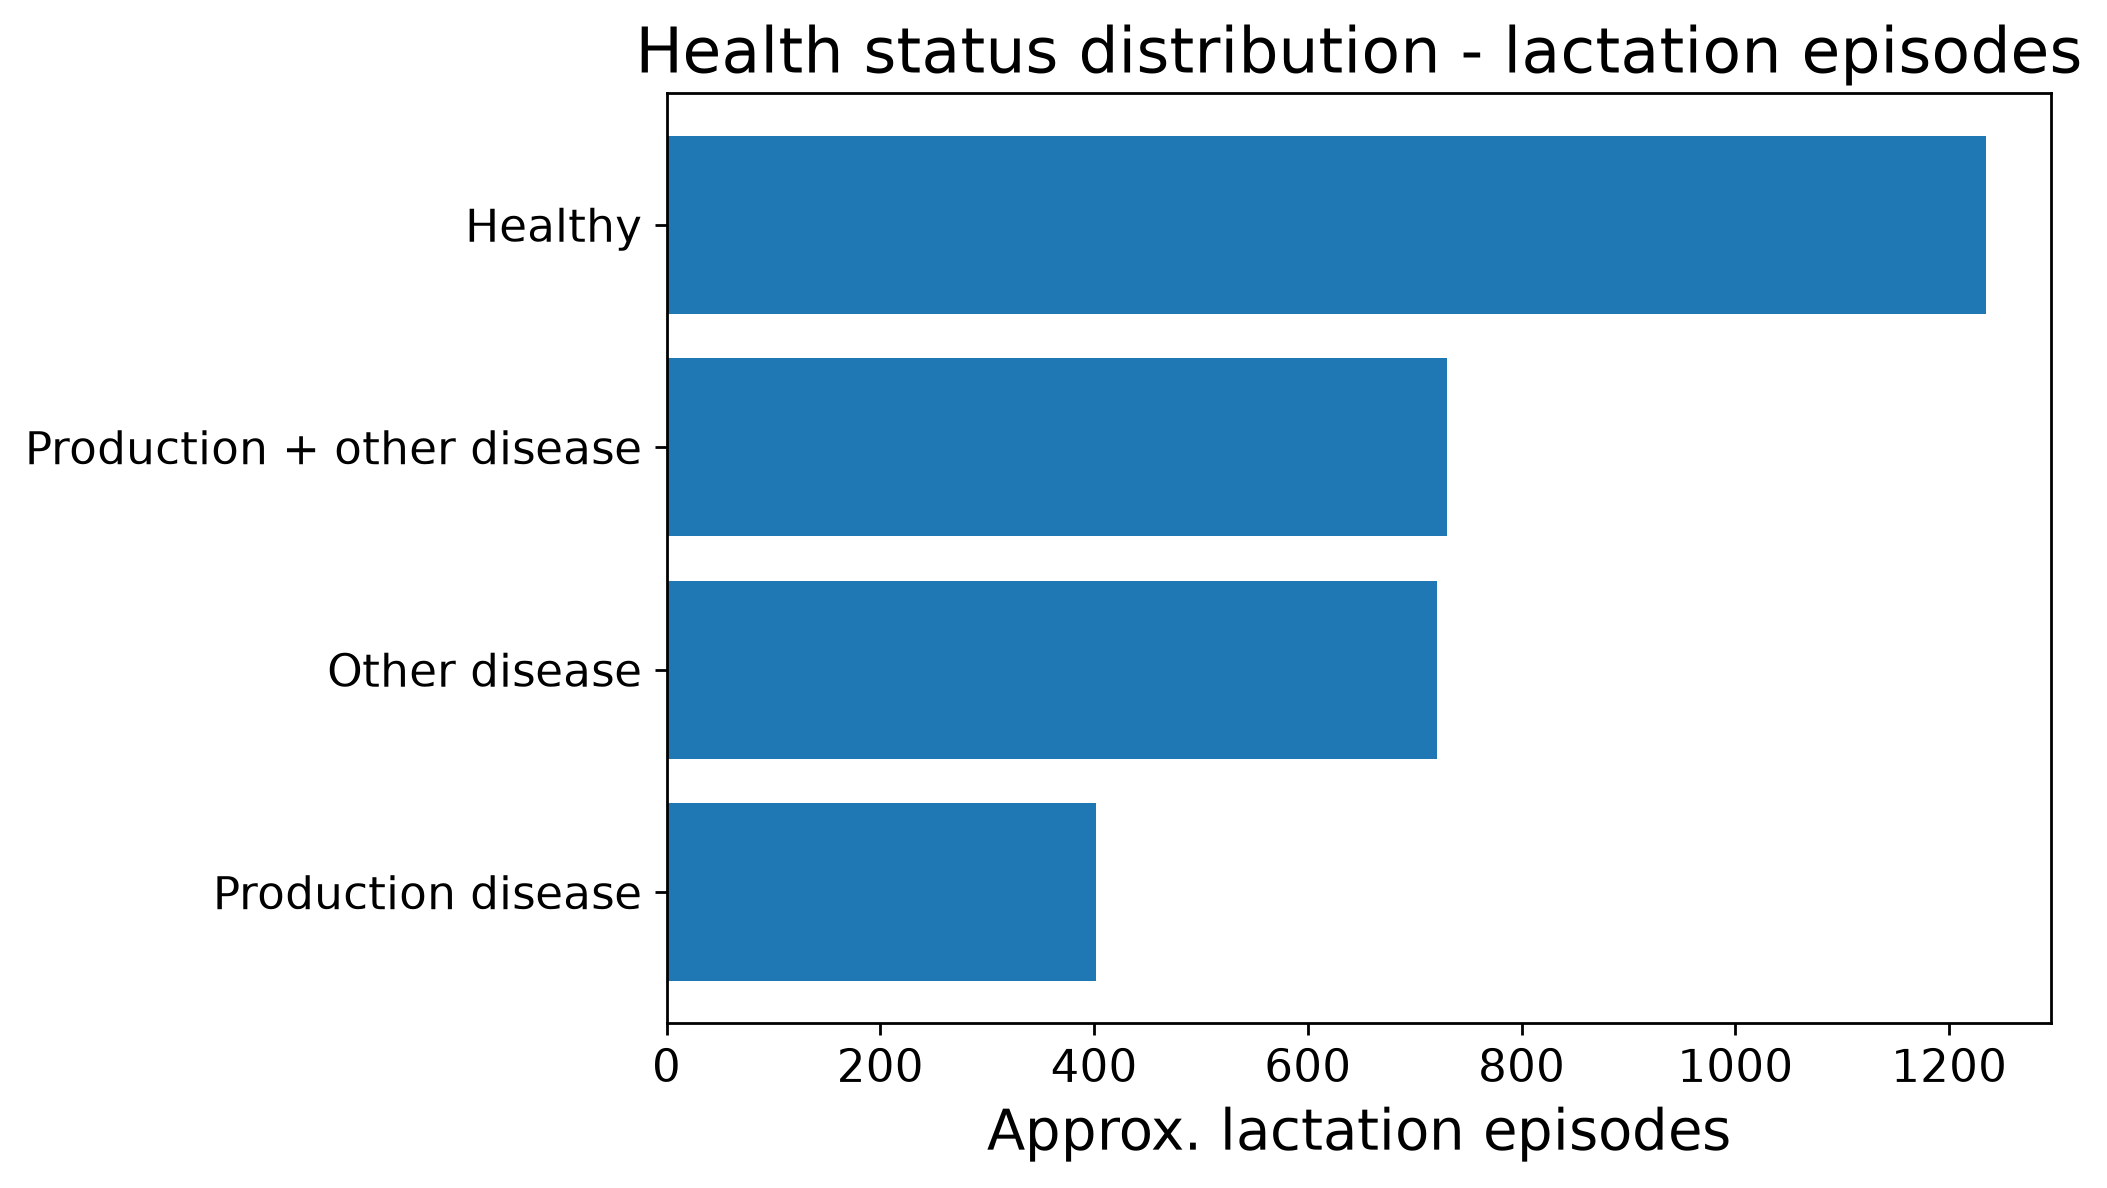

fig06_records_over_time.png


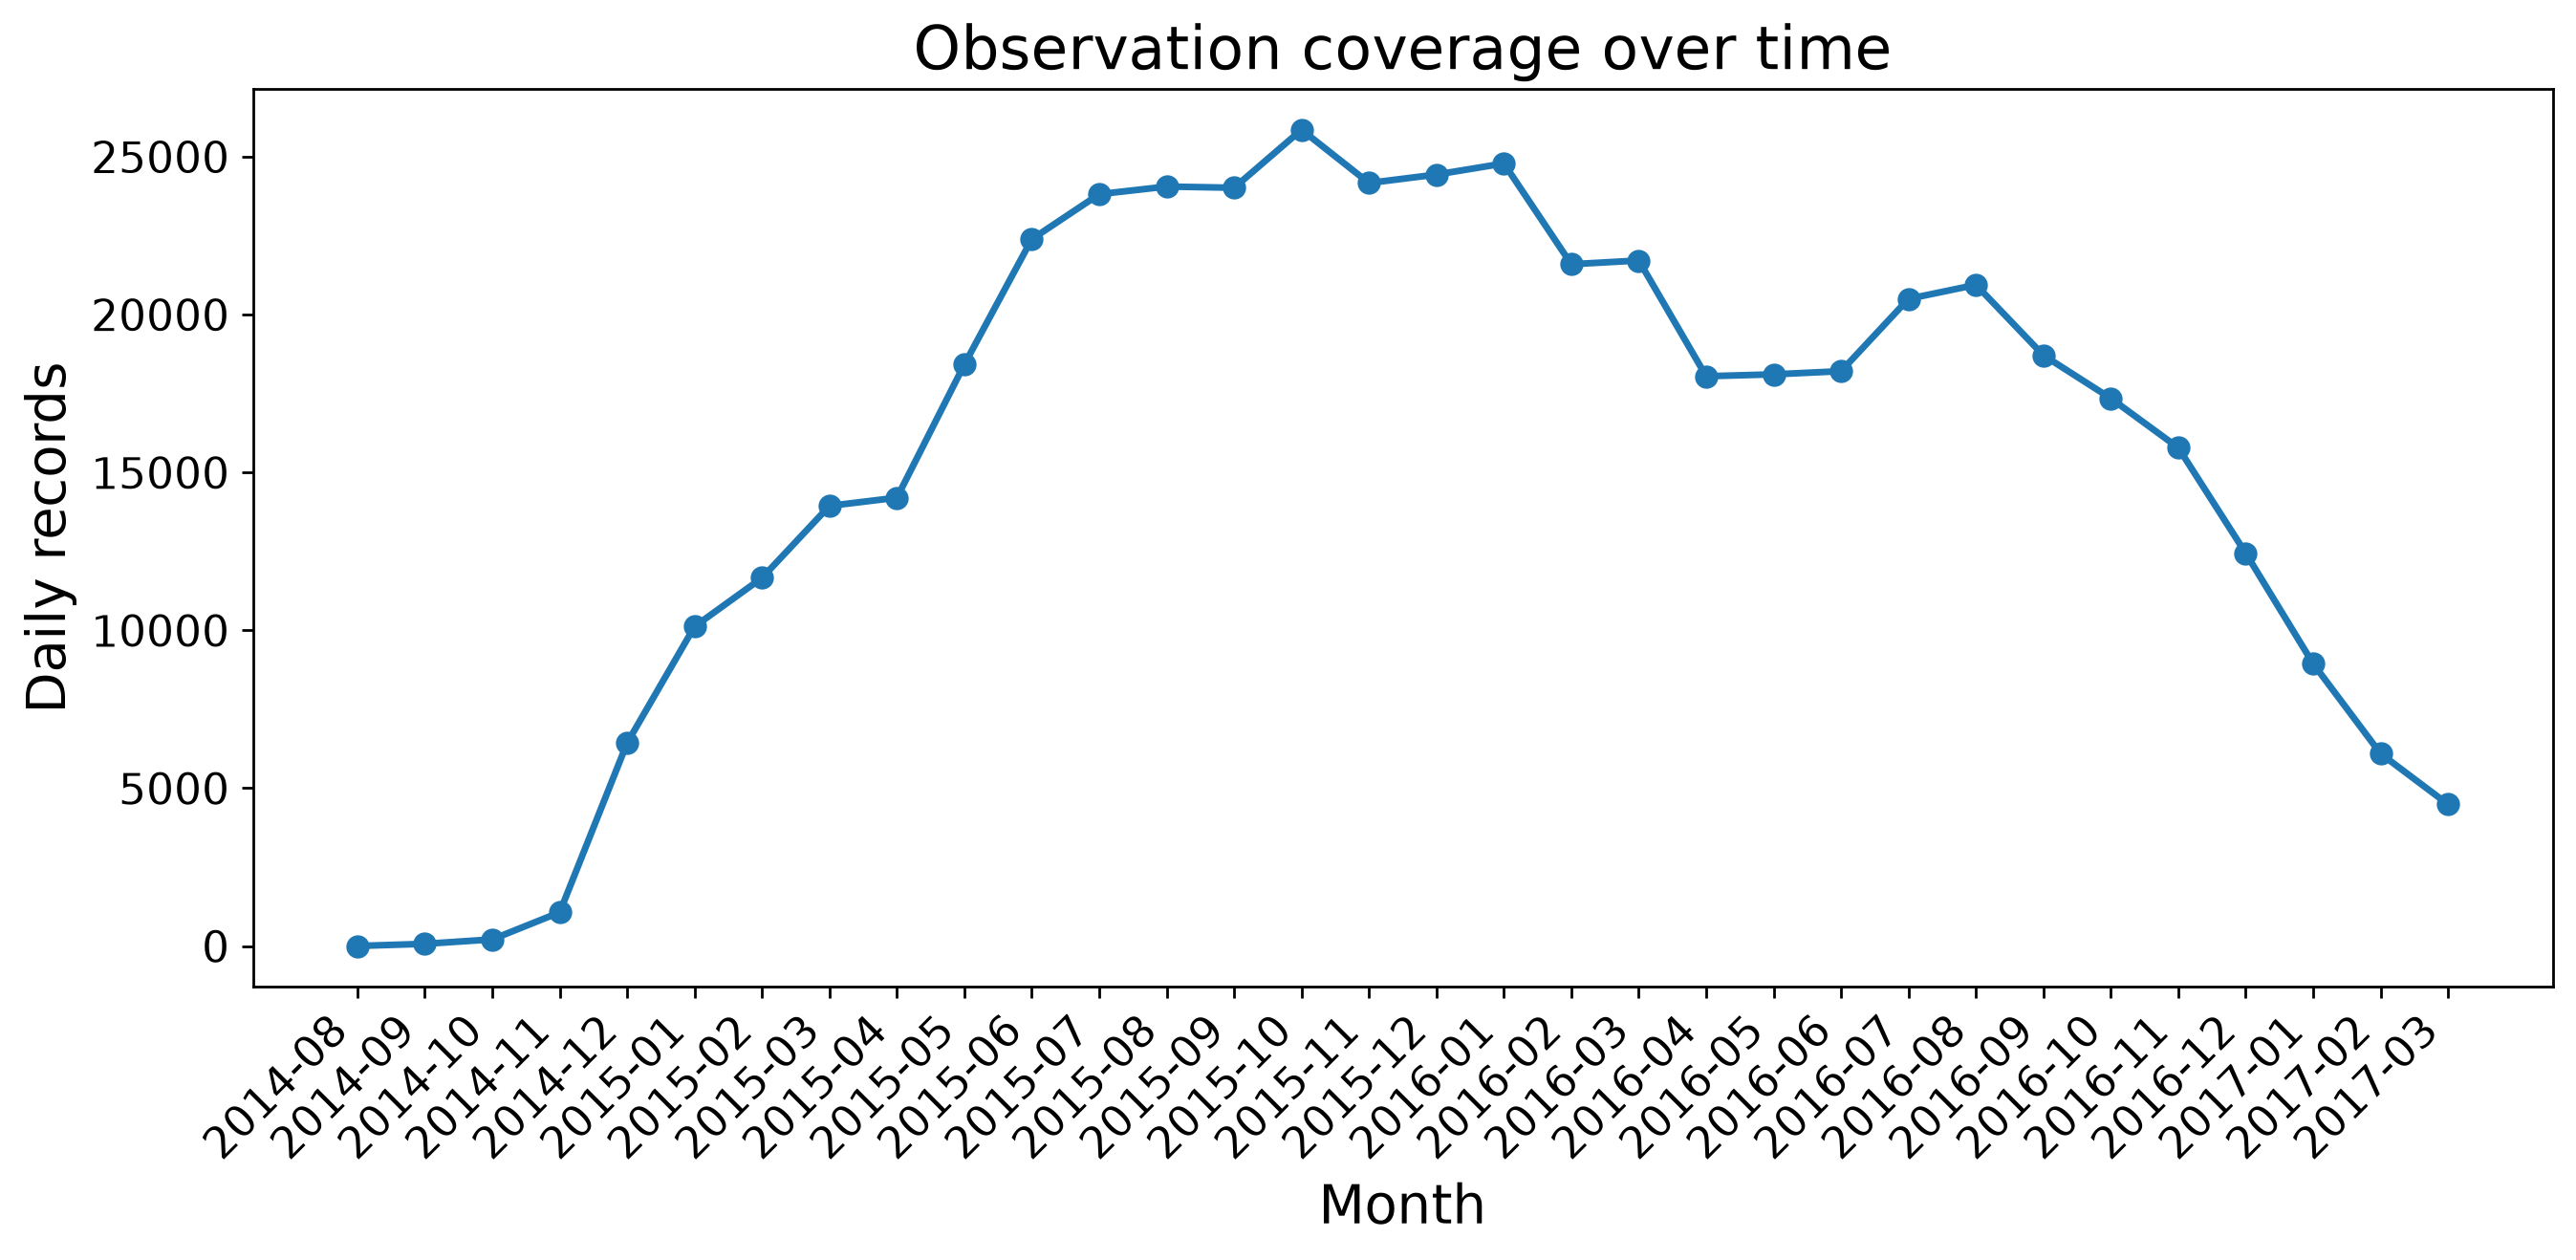

fig07_missingness_top20.png


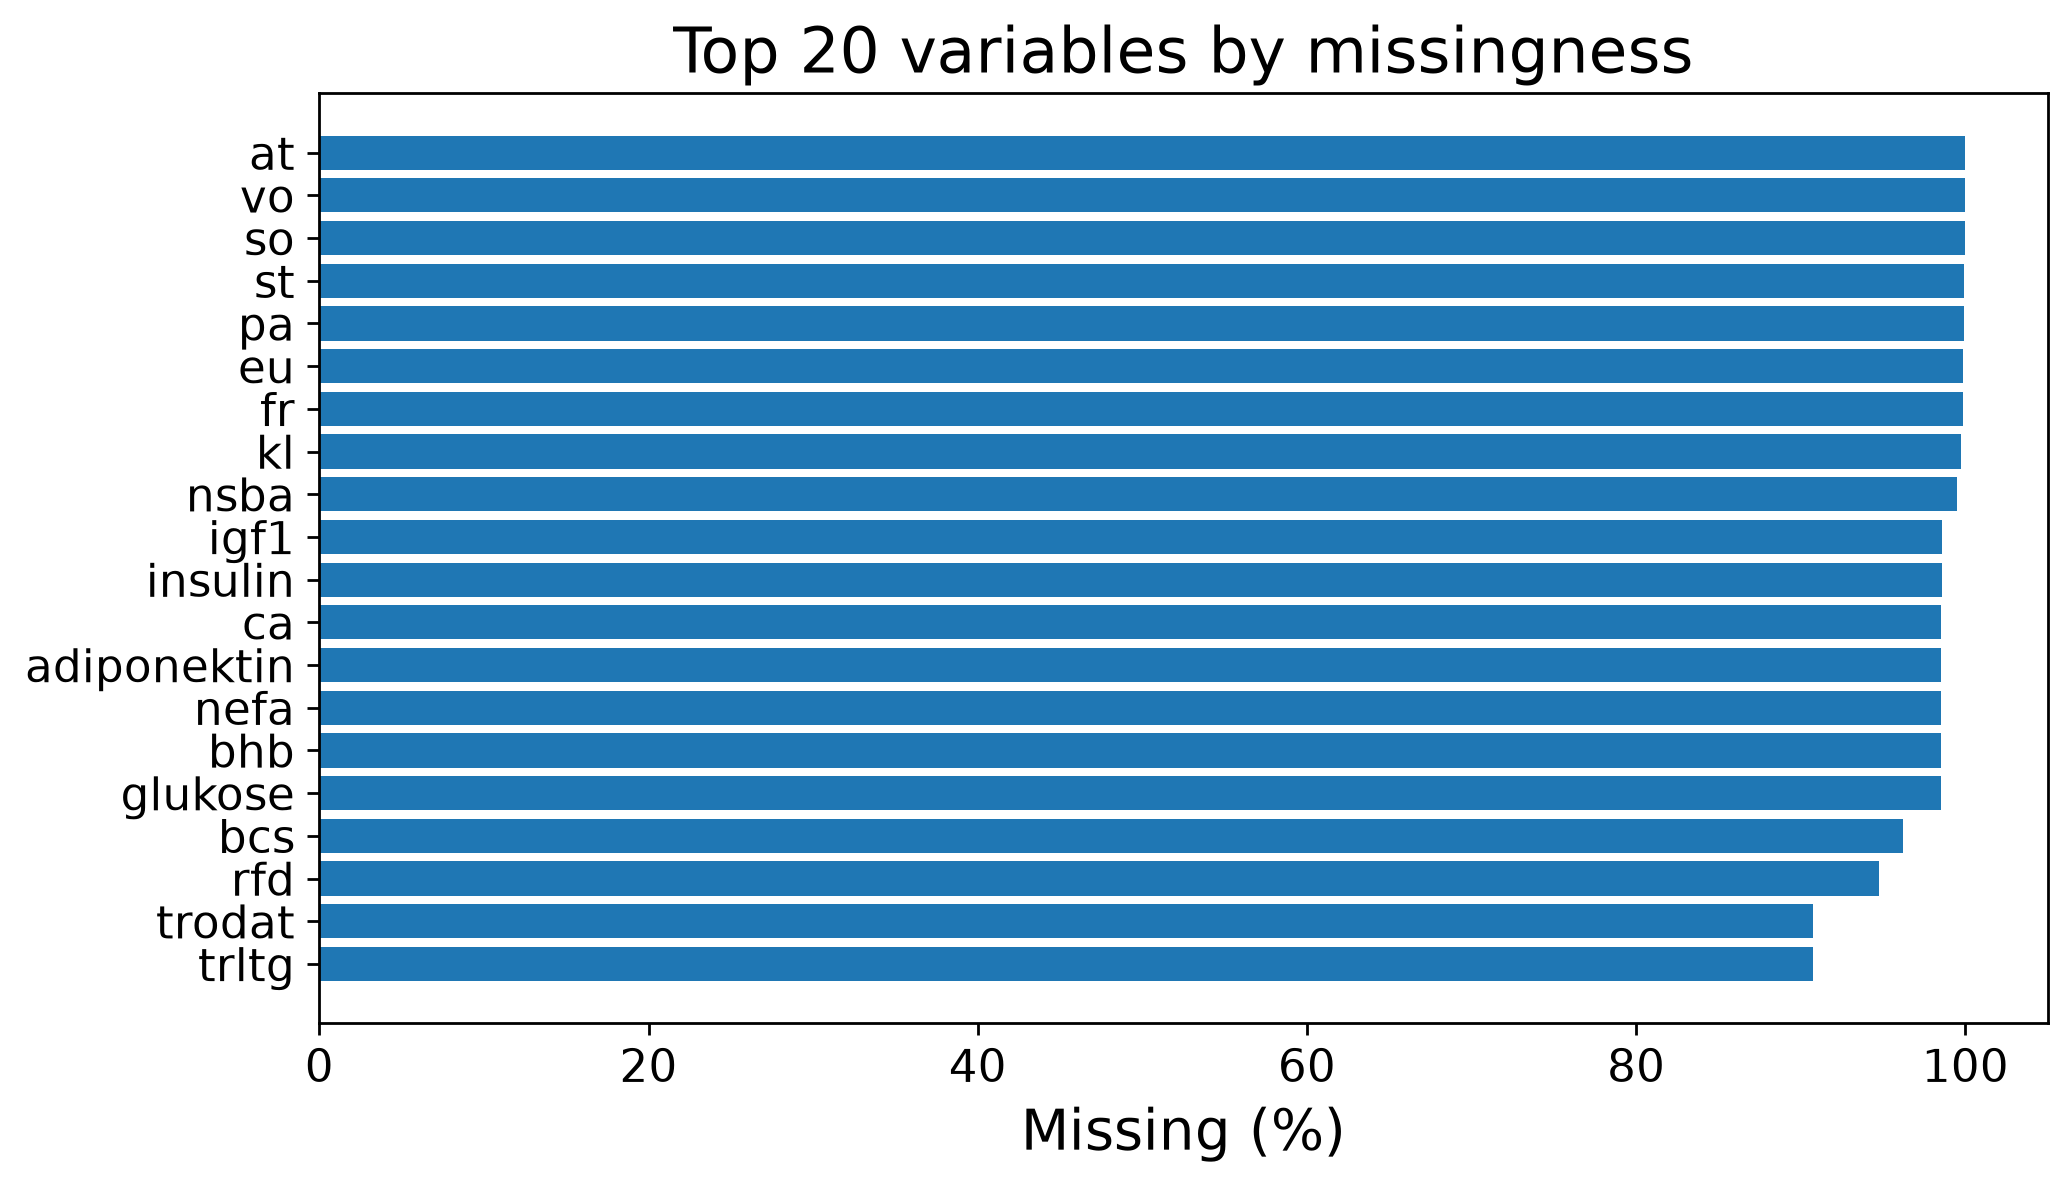

fig17_health_status_by_farm_percent.png


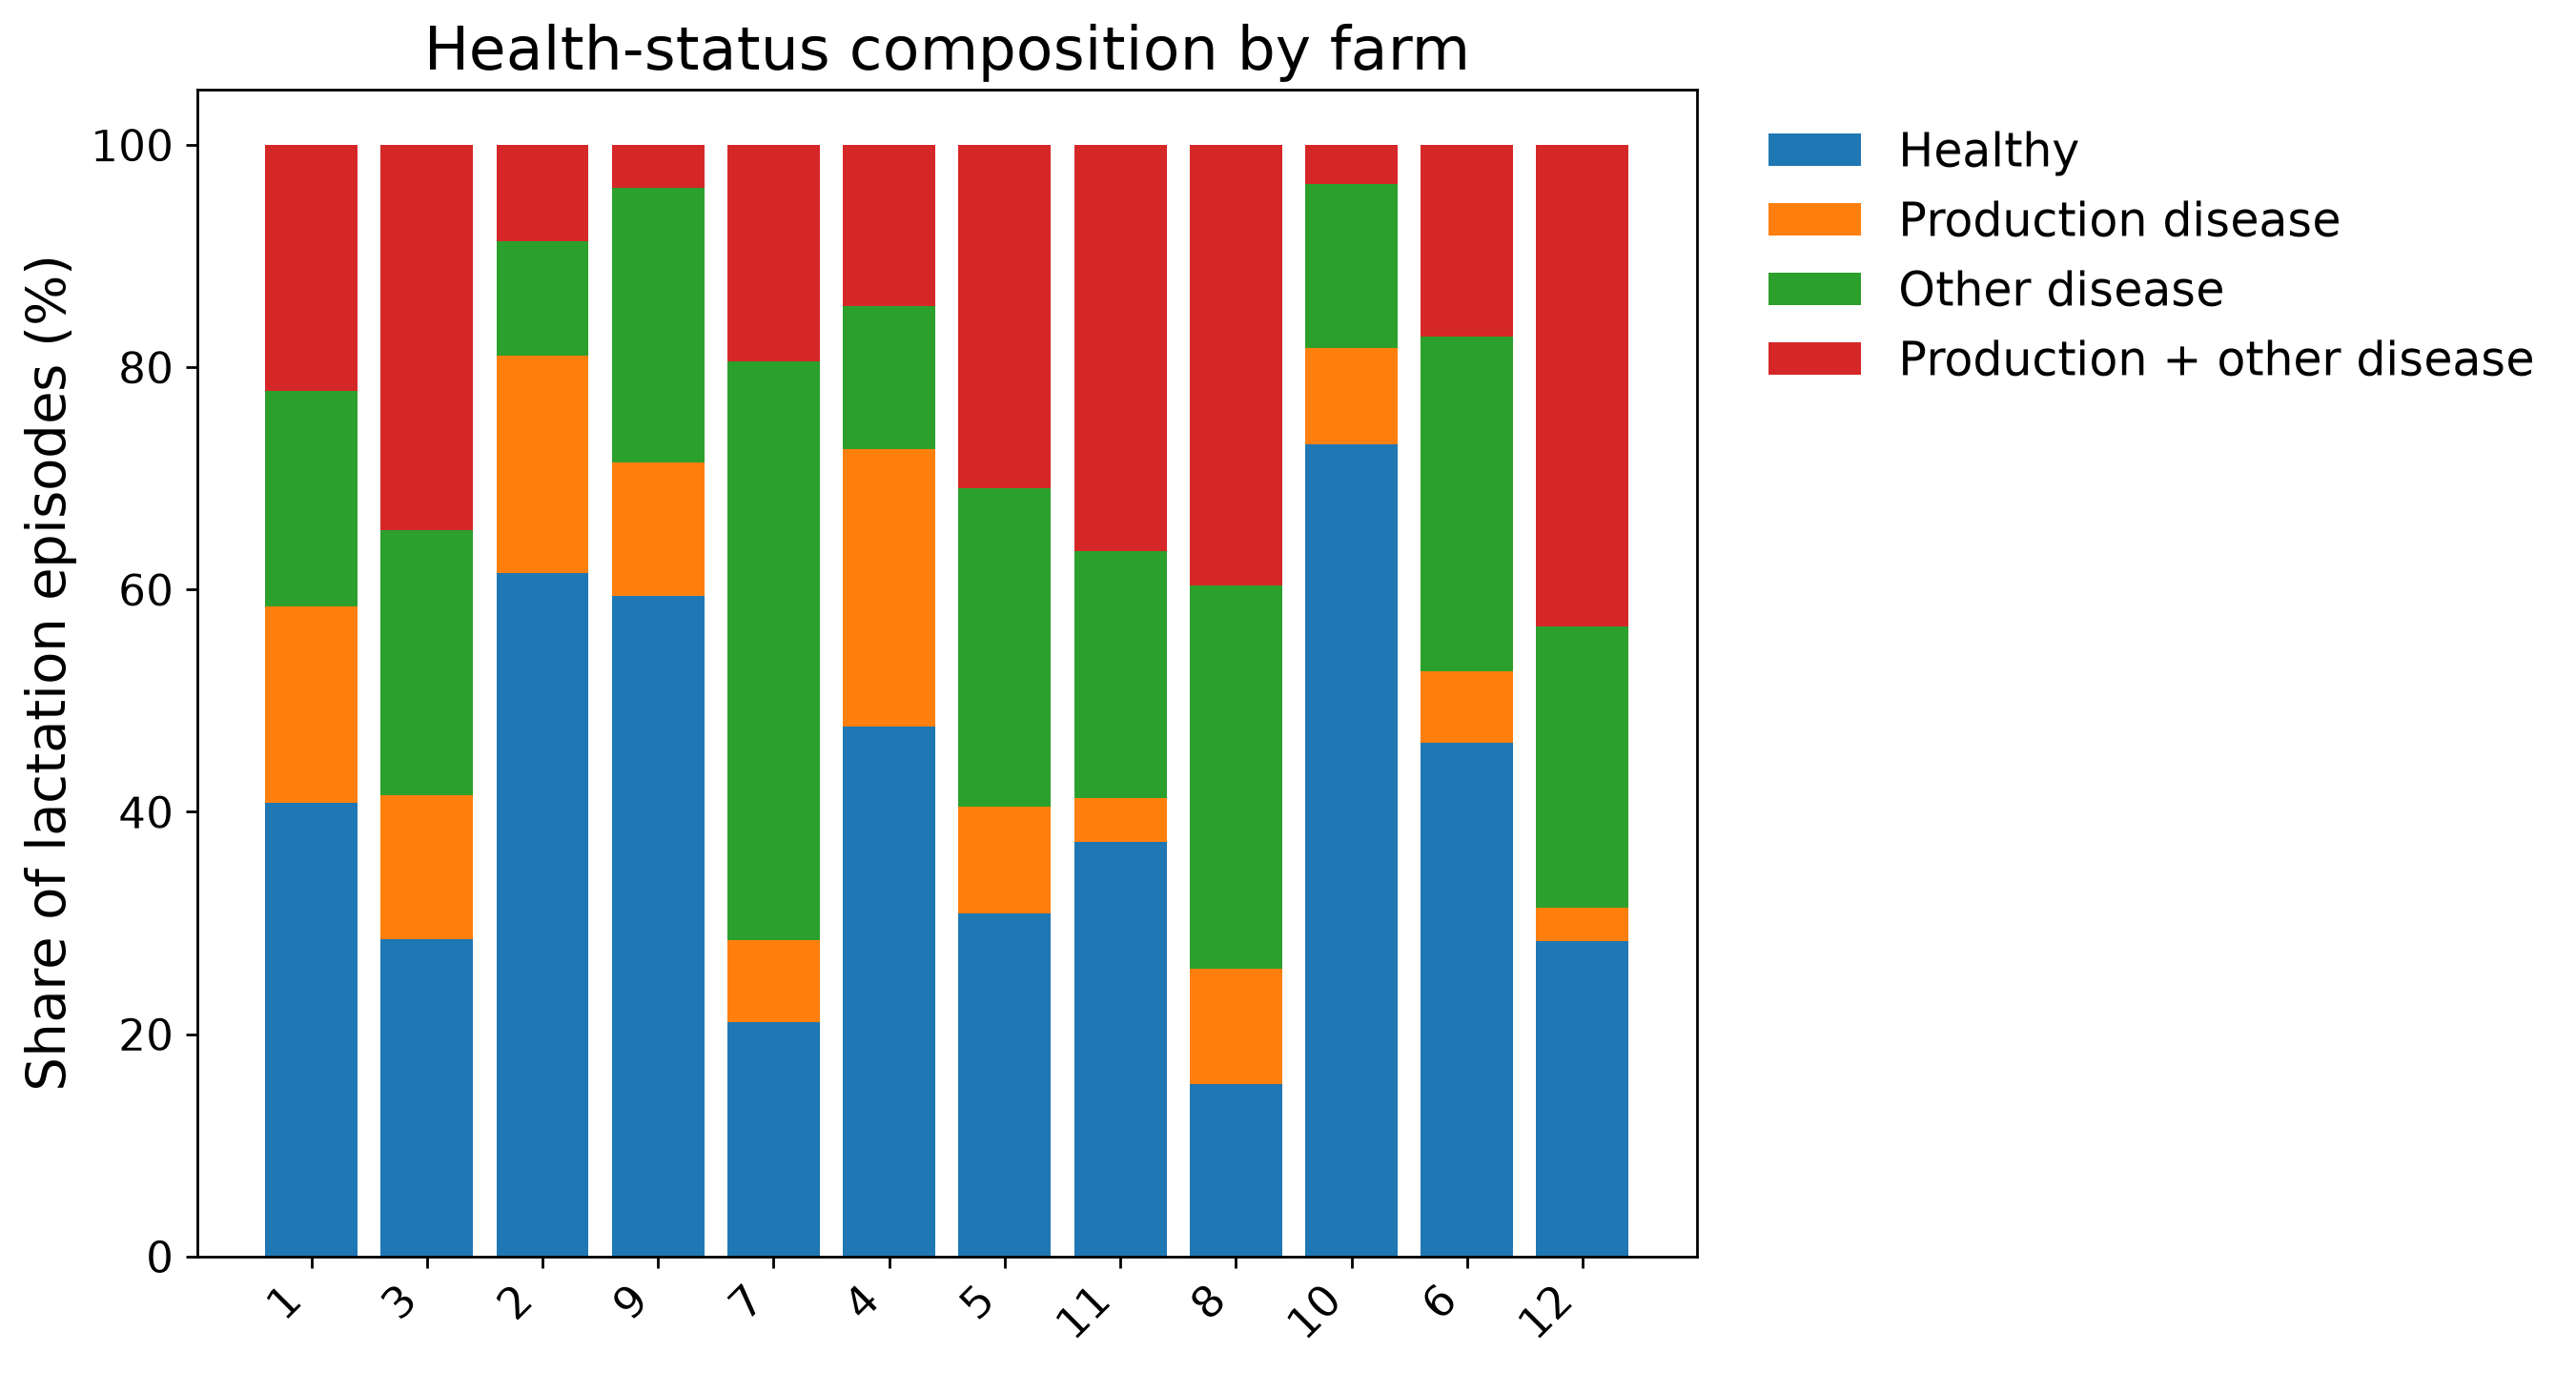

fig18_health_status_by_breed_percent.png


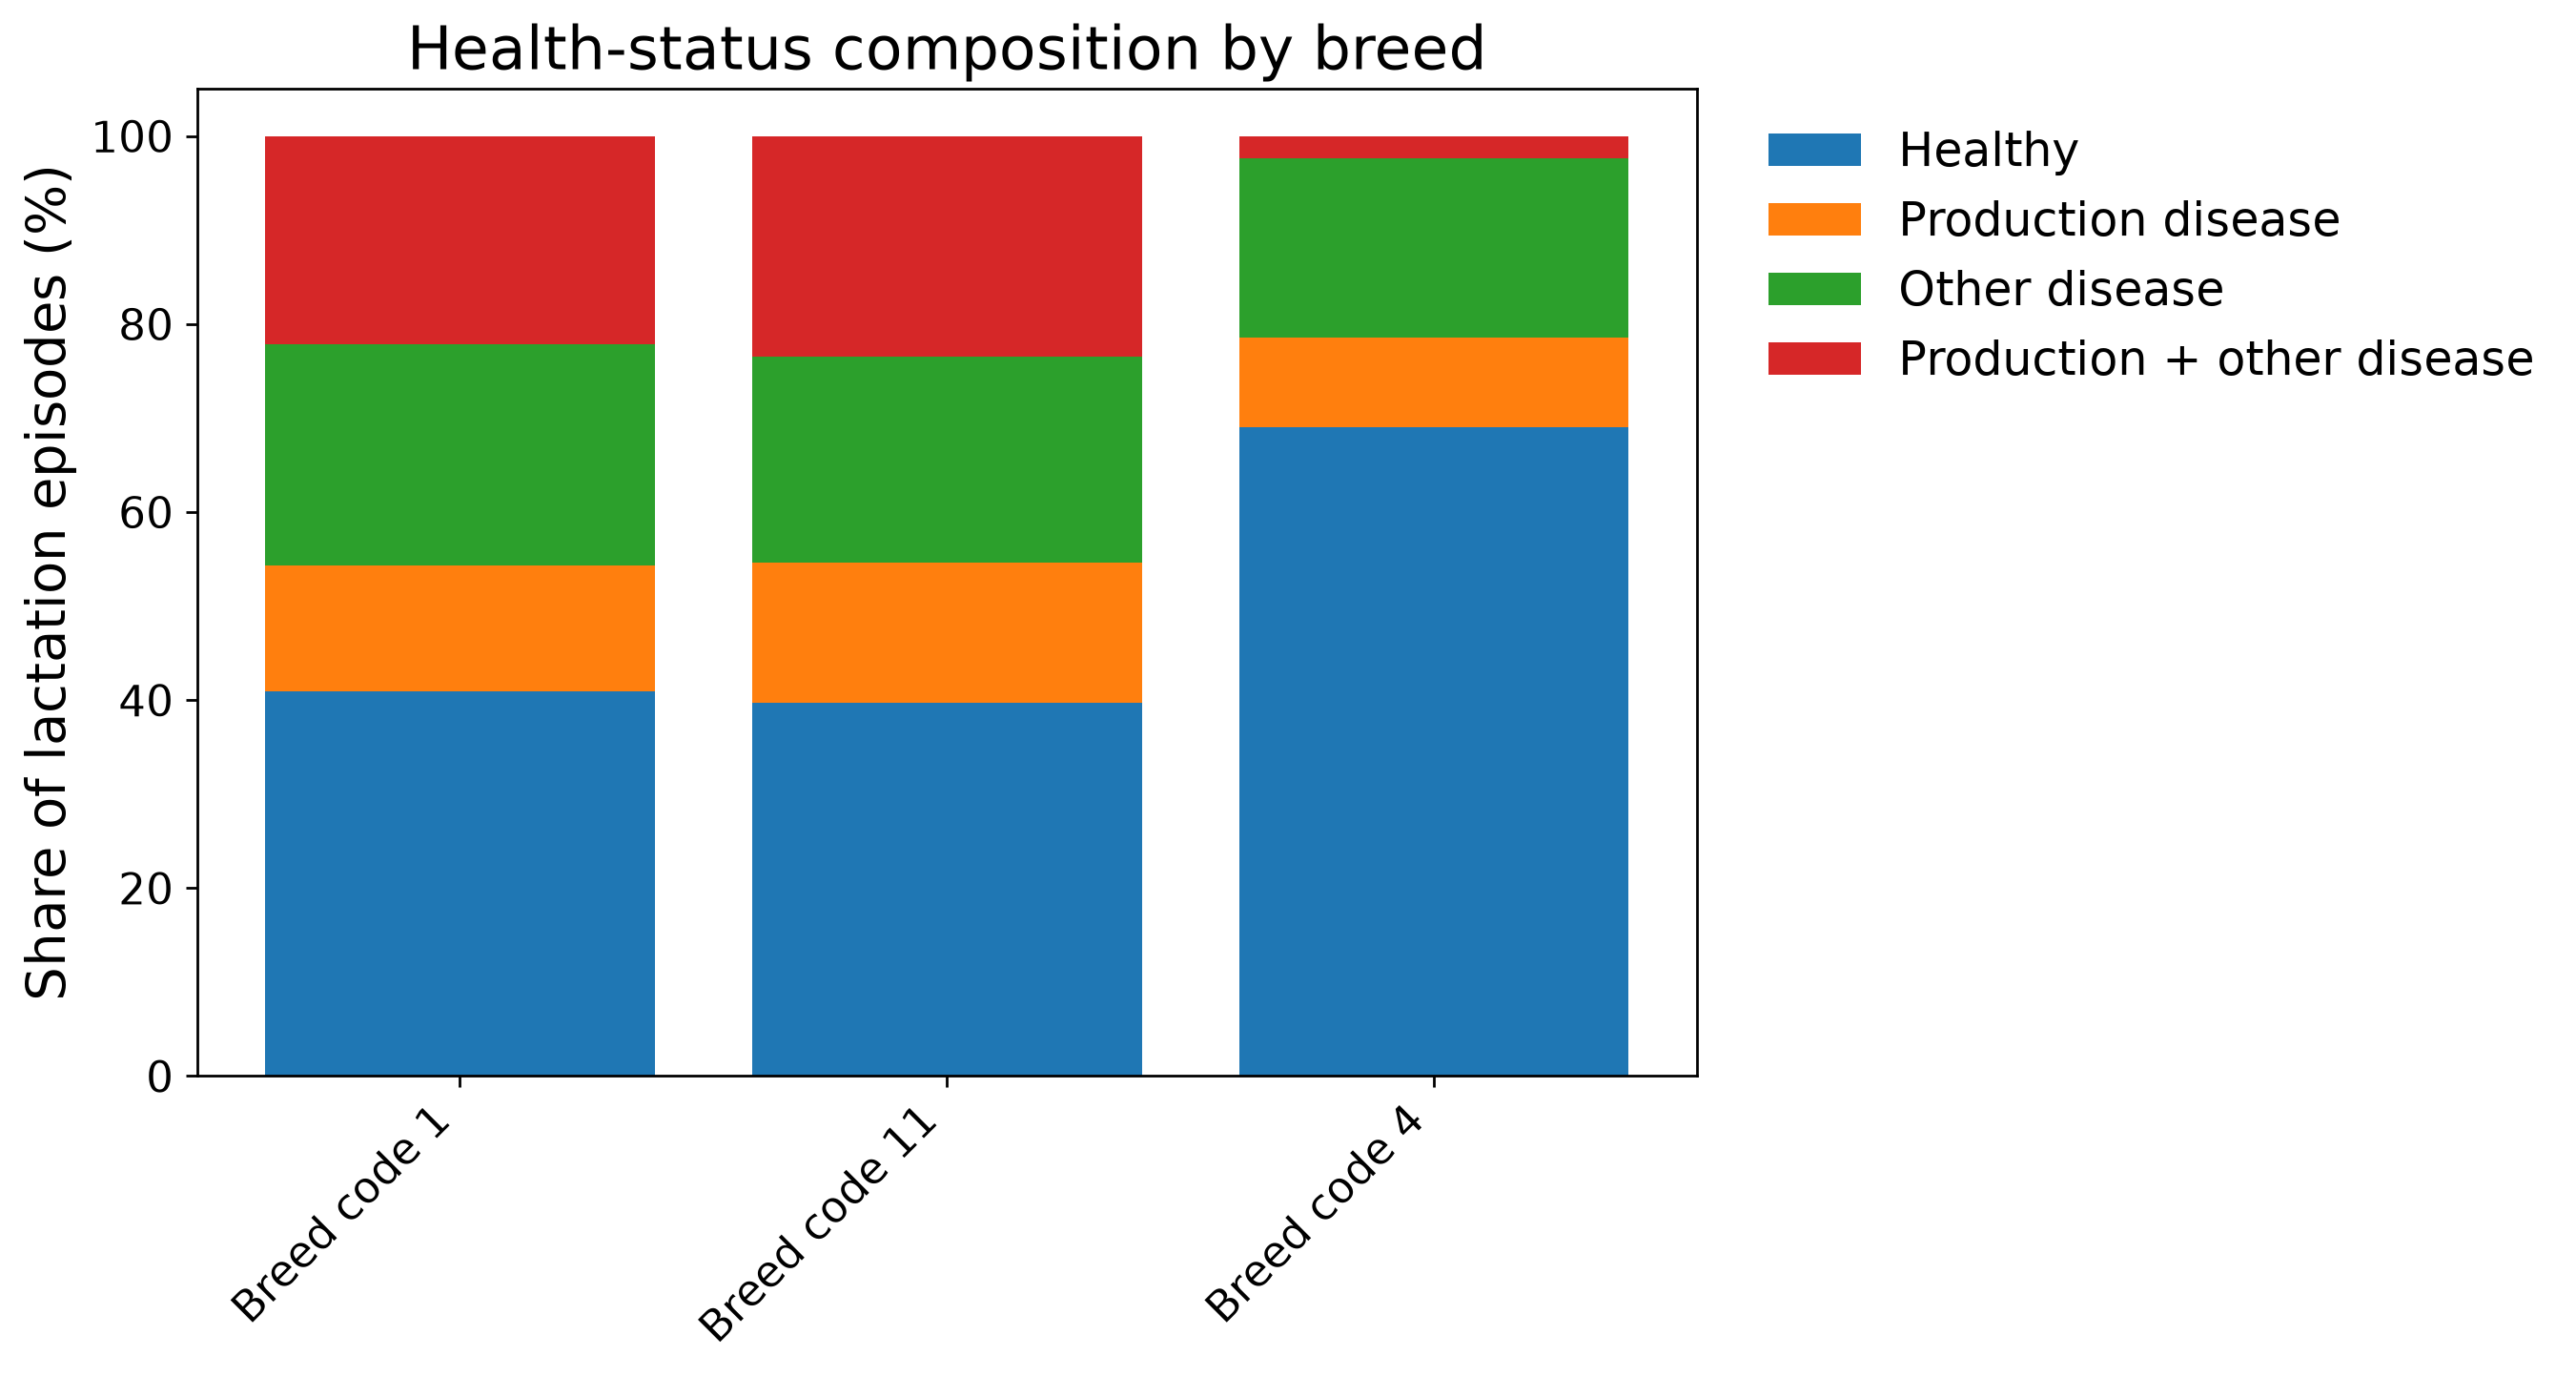

Missing: fig19_health_status_by_lactation_percent.png
fig20_production_disease_rate_by_farm.png


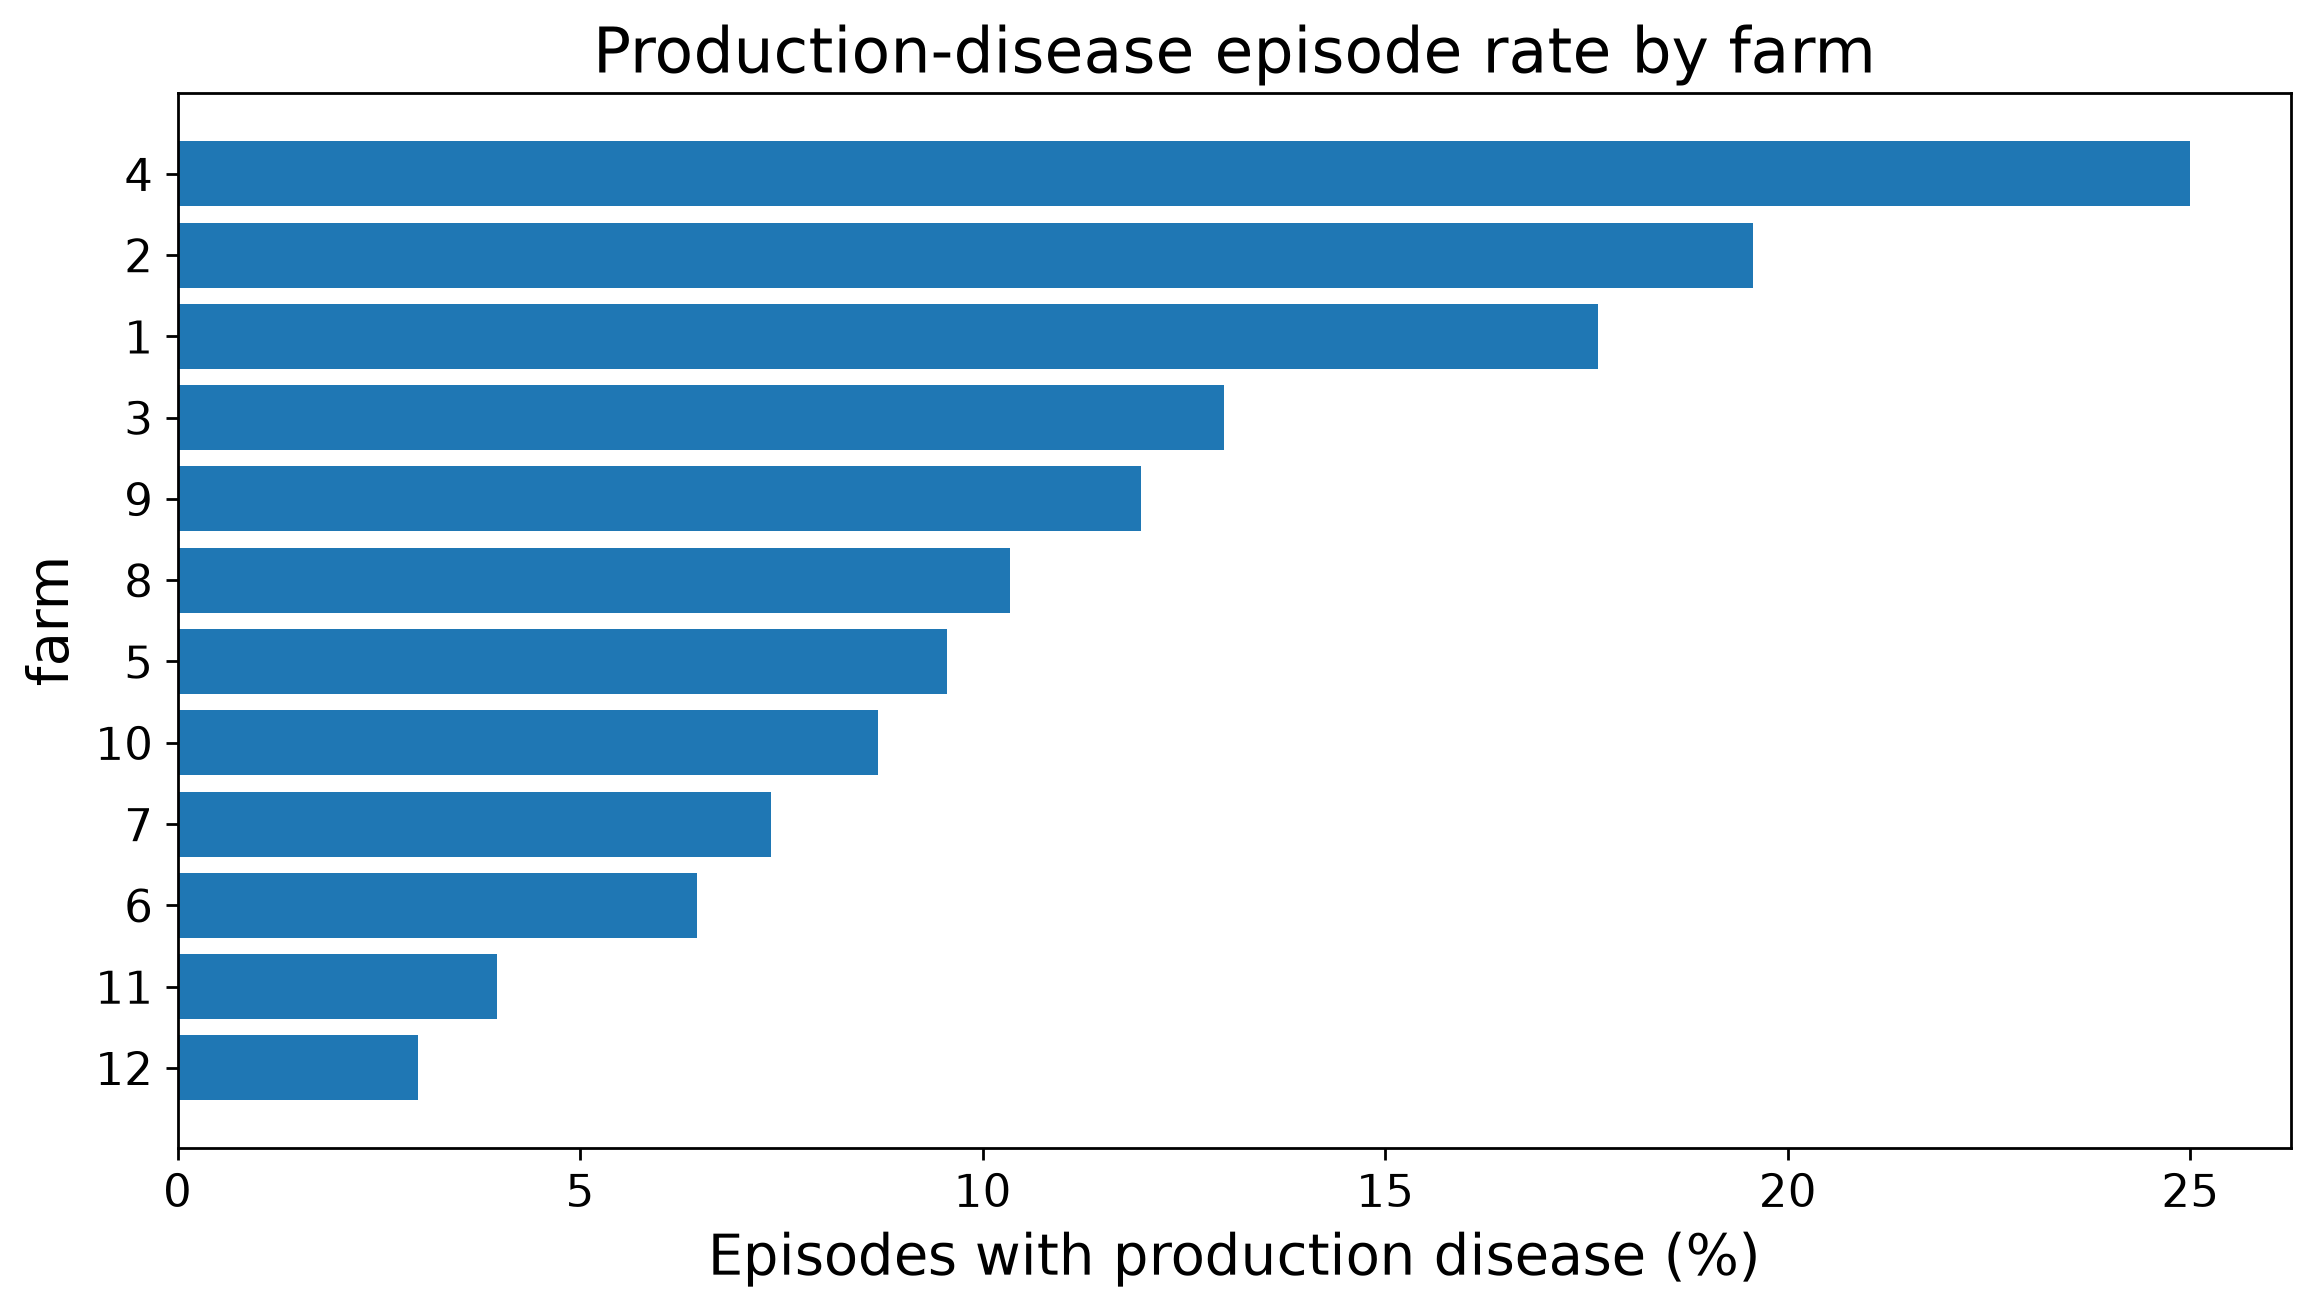

fig22_monthly_health_status_coverage.png


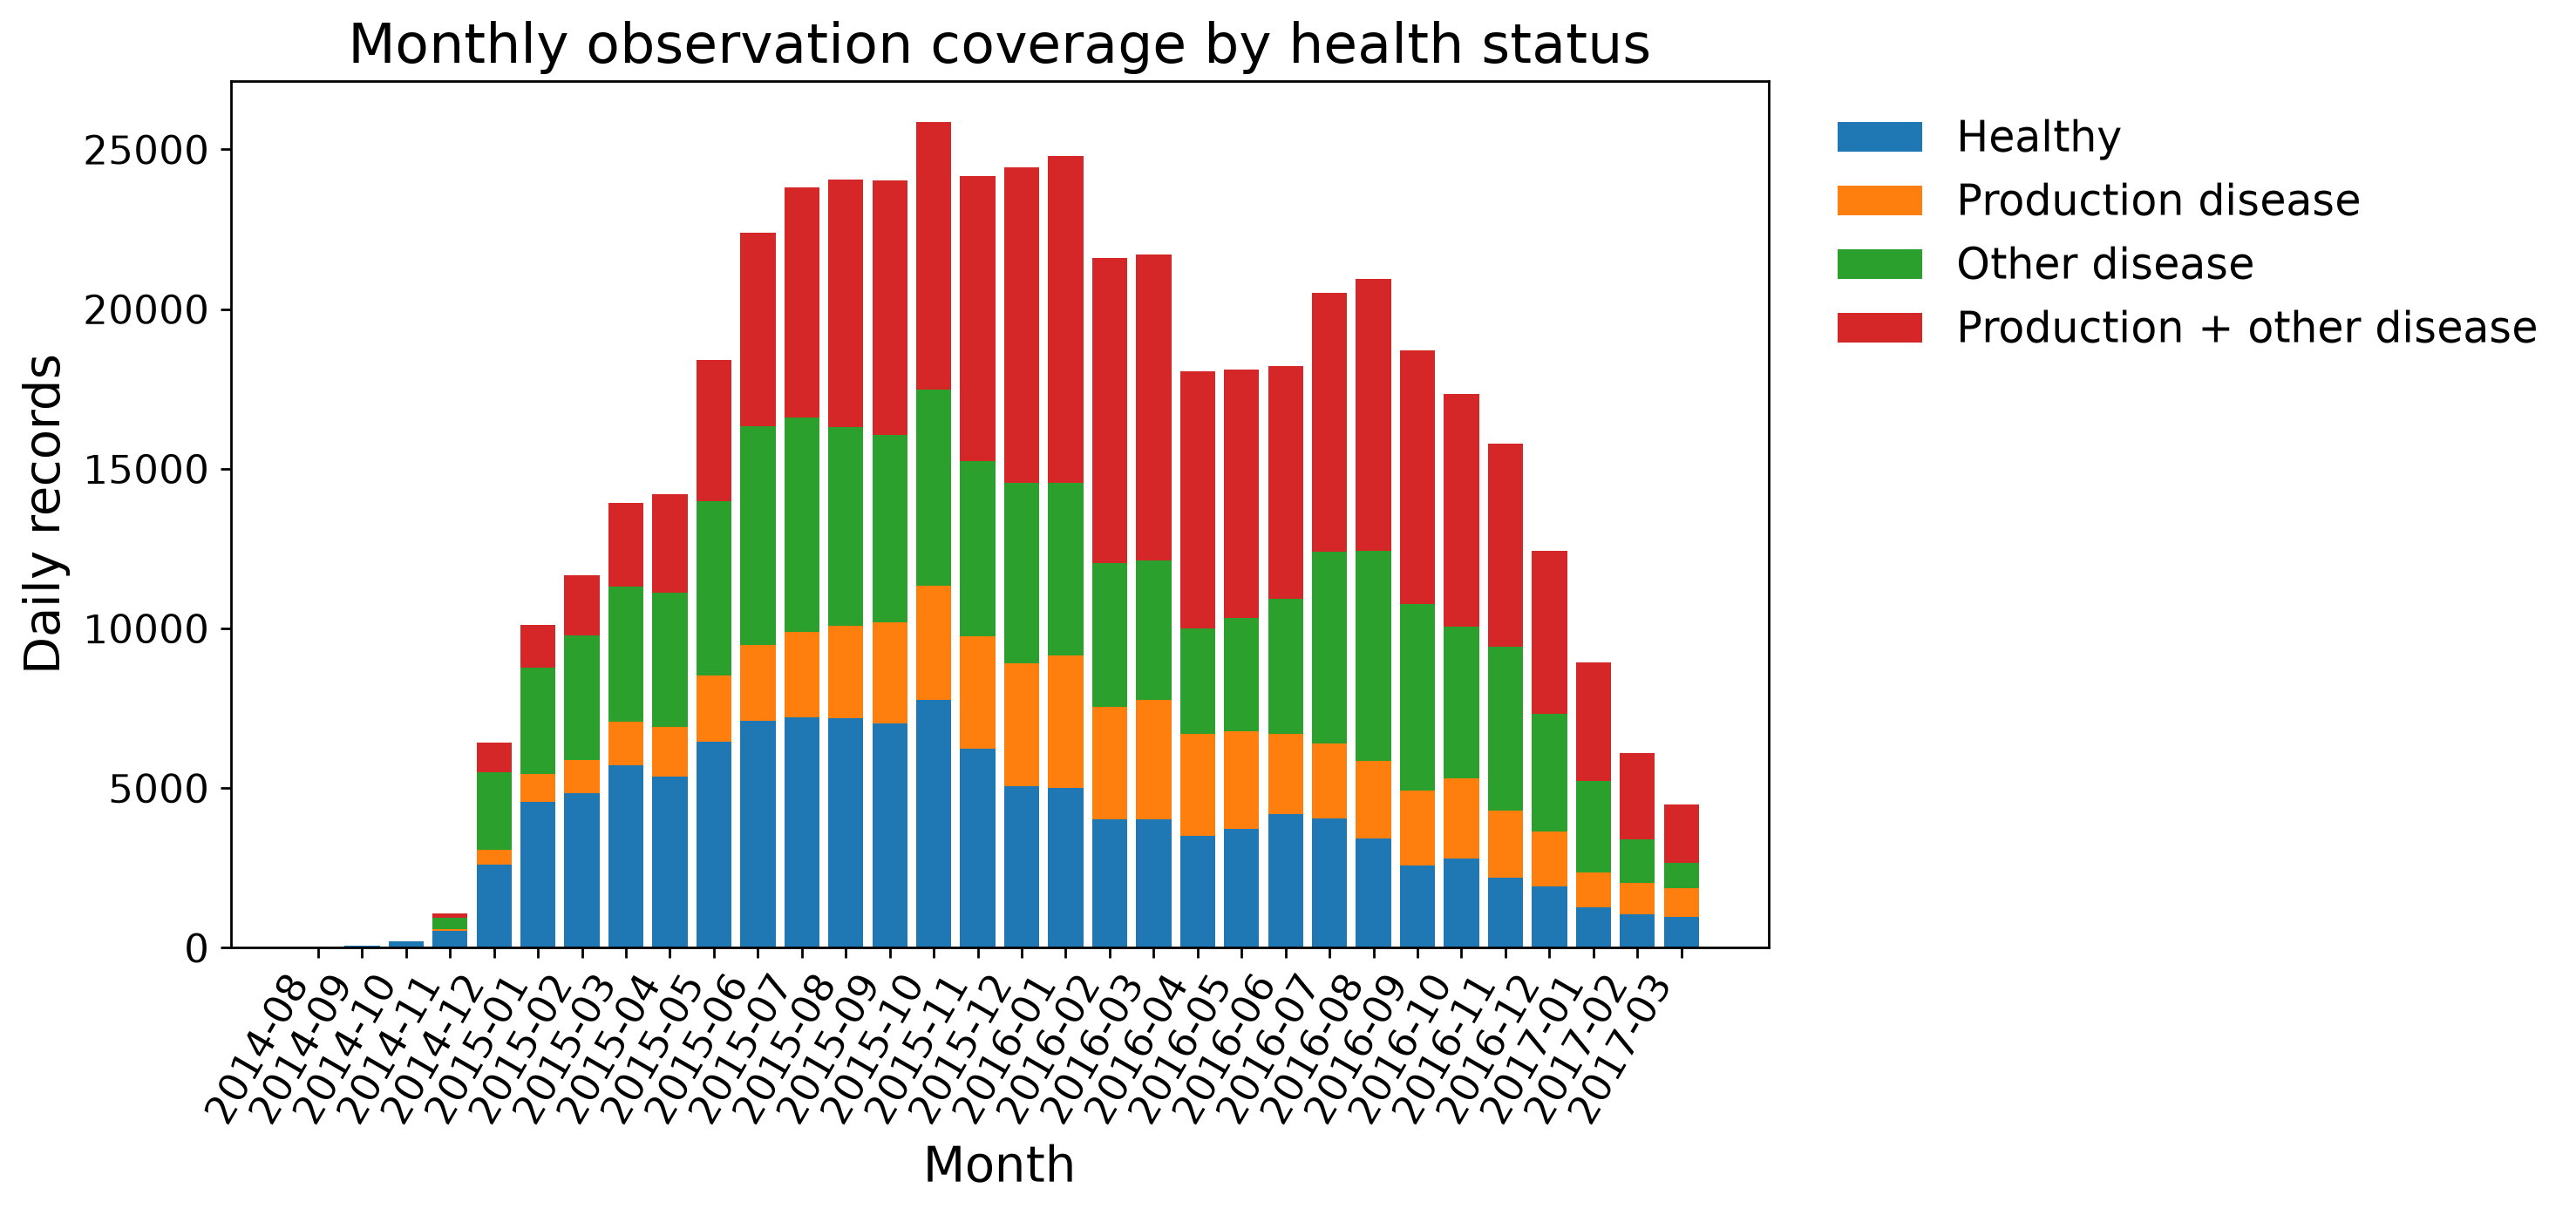

fig23_milk_yield_dim_trend_by_health_status.png


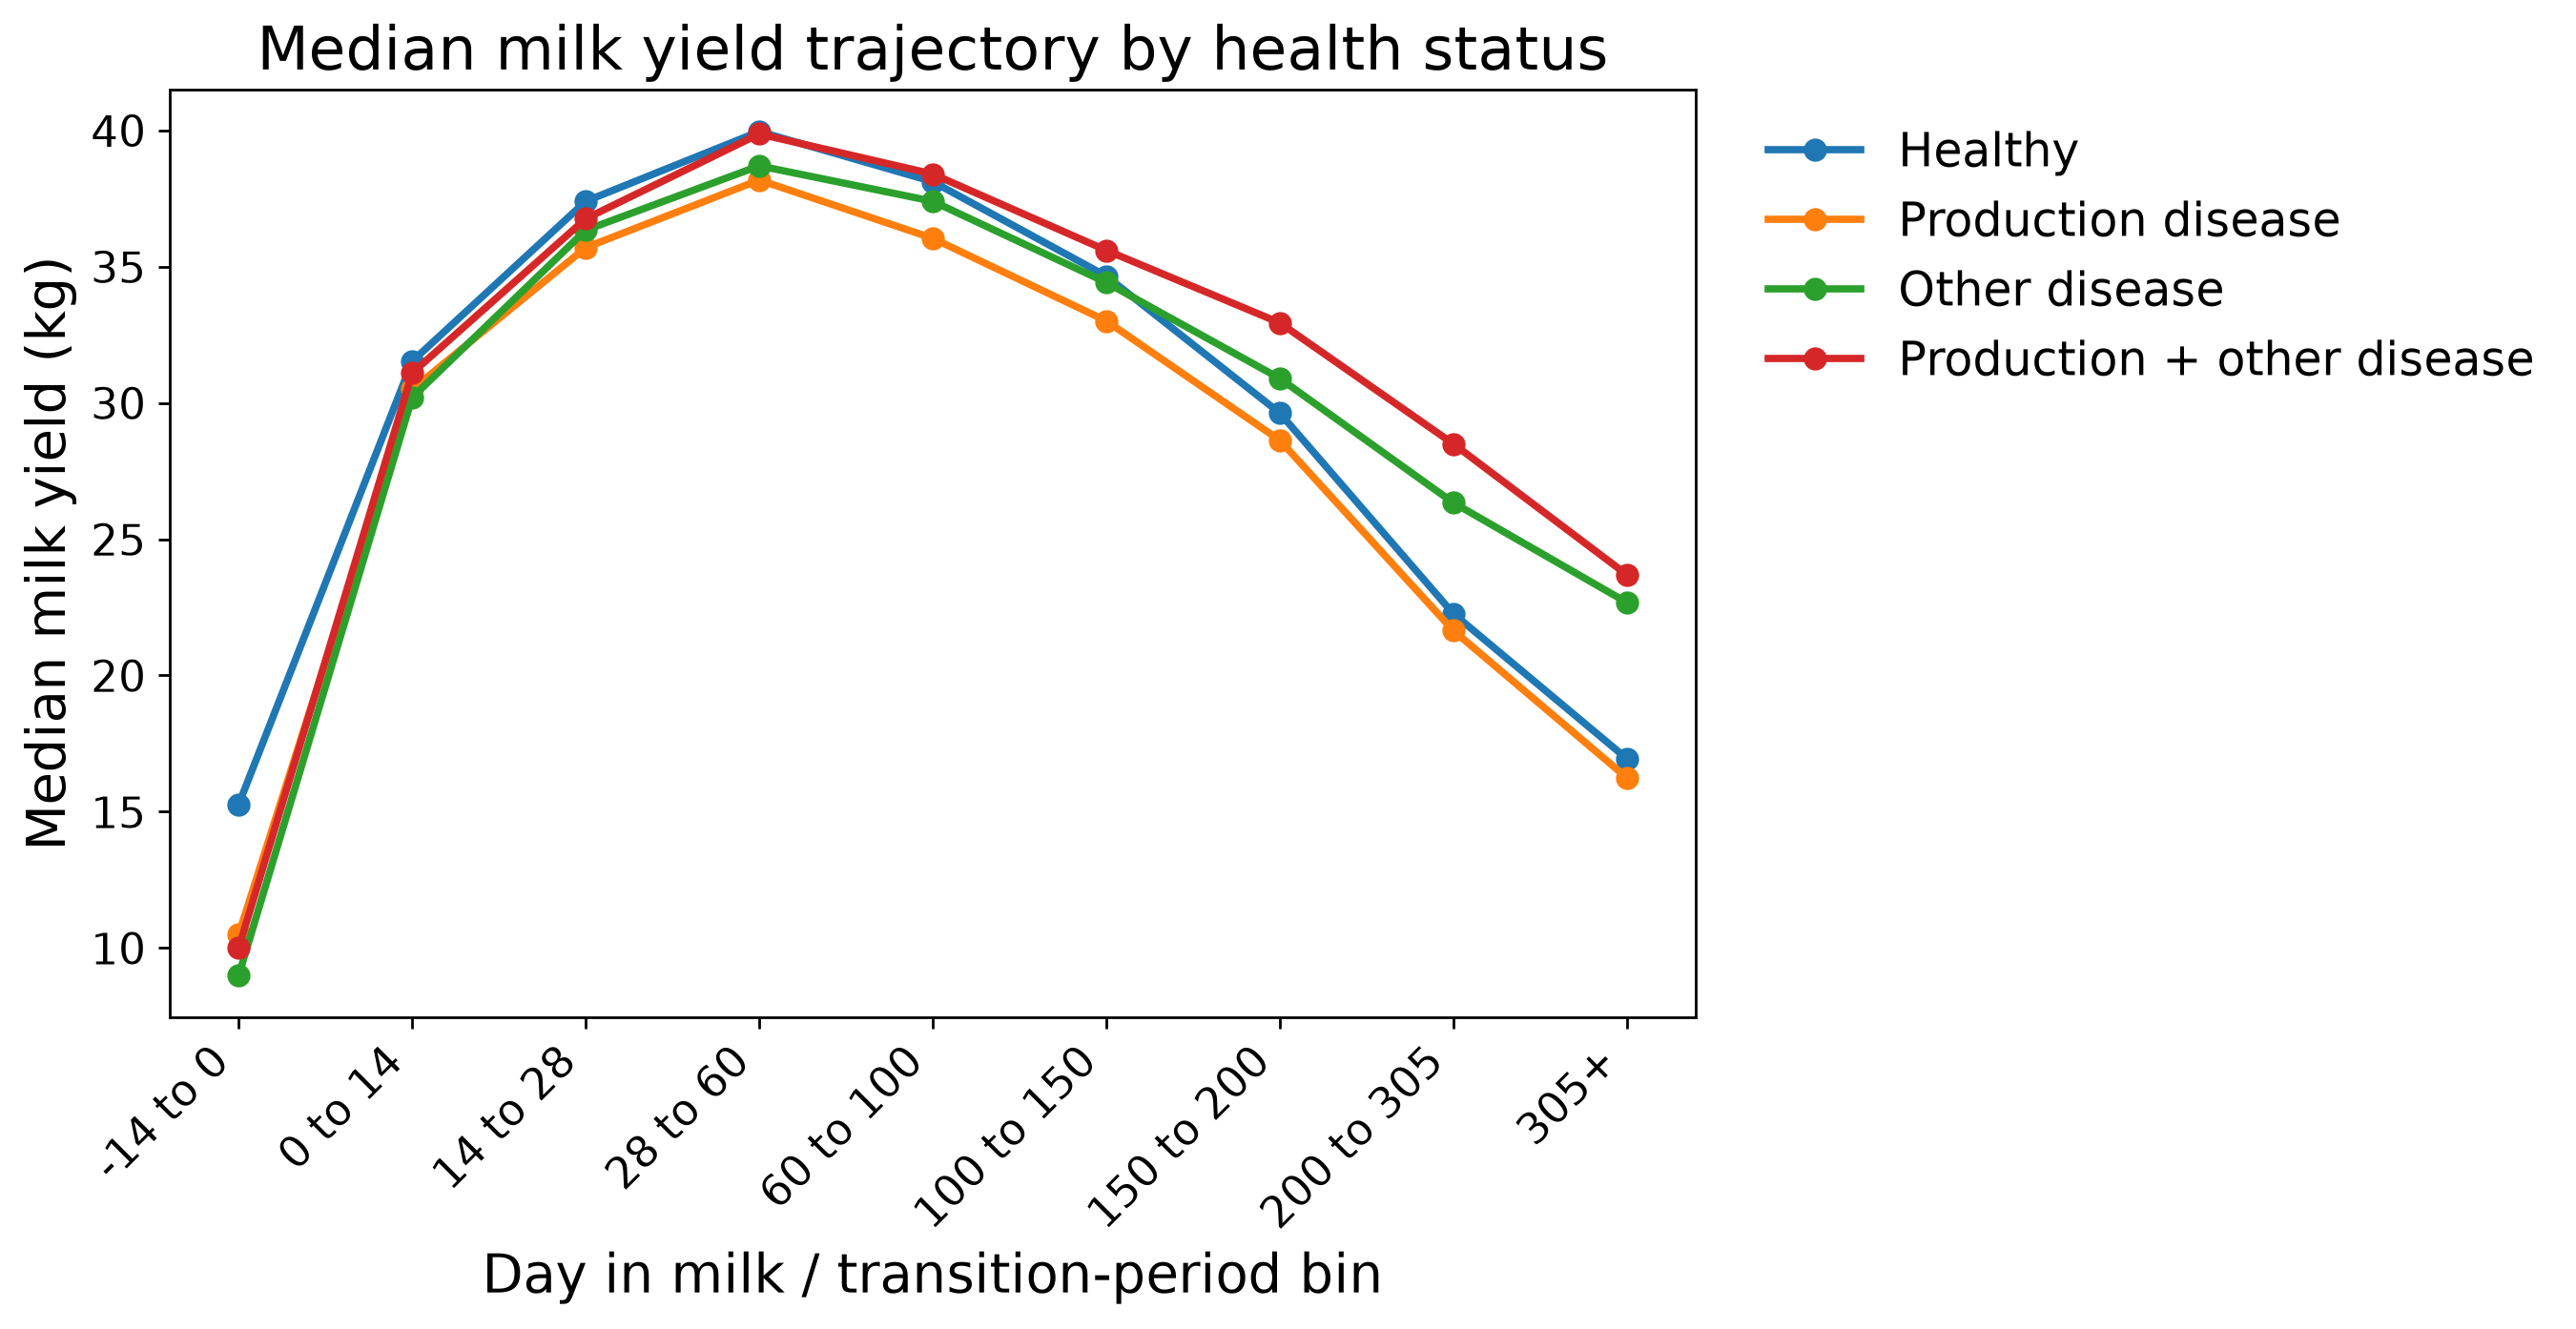

fig24_bhb_dim_trend_by_health_status.png


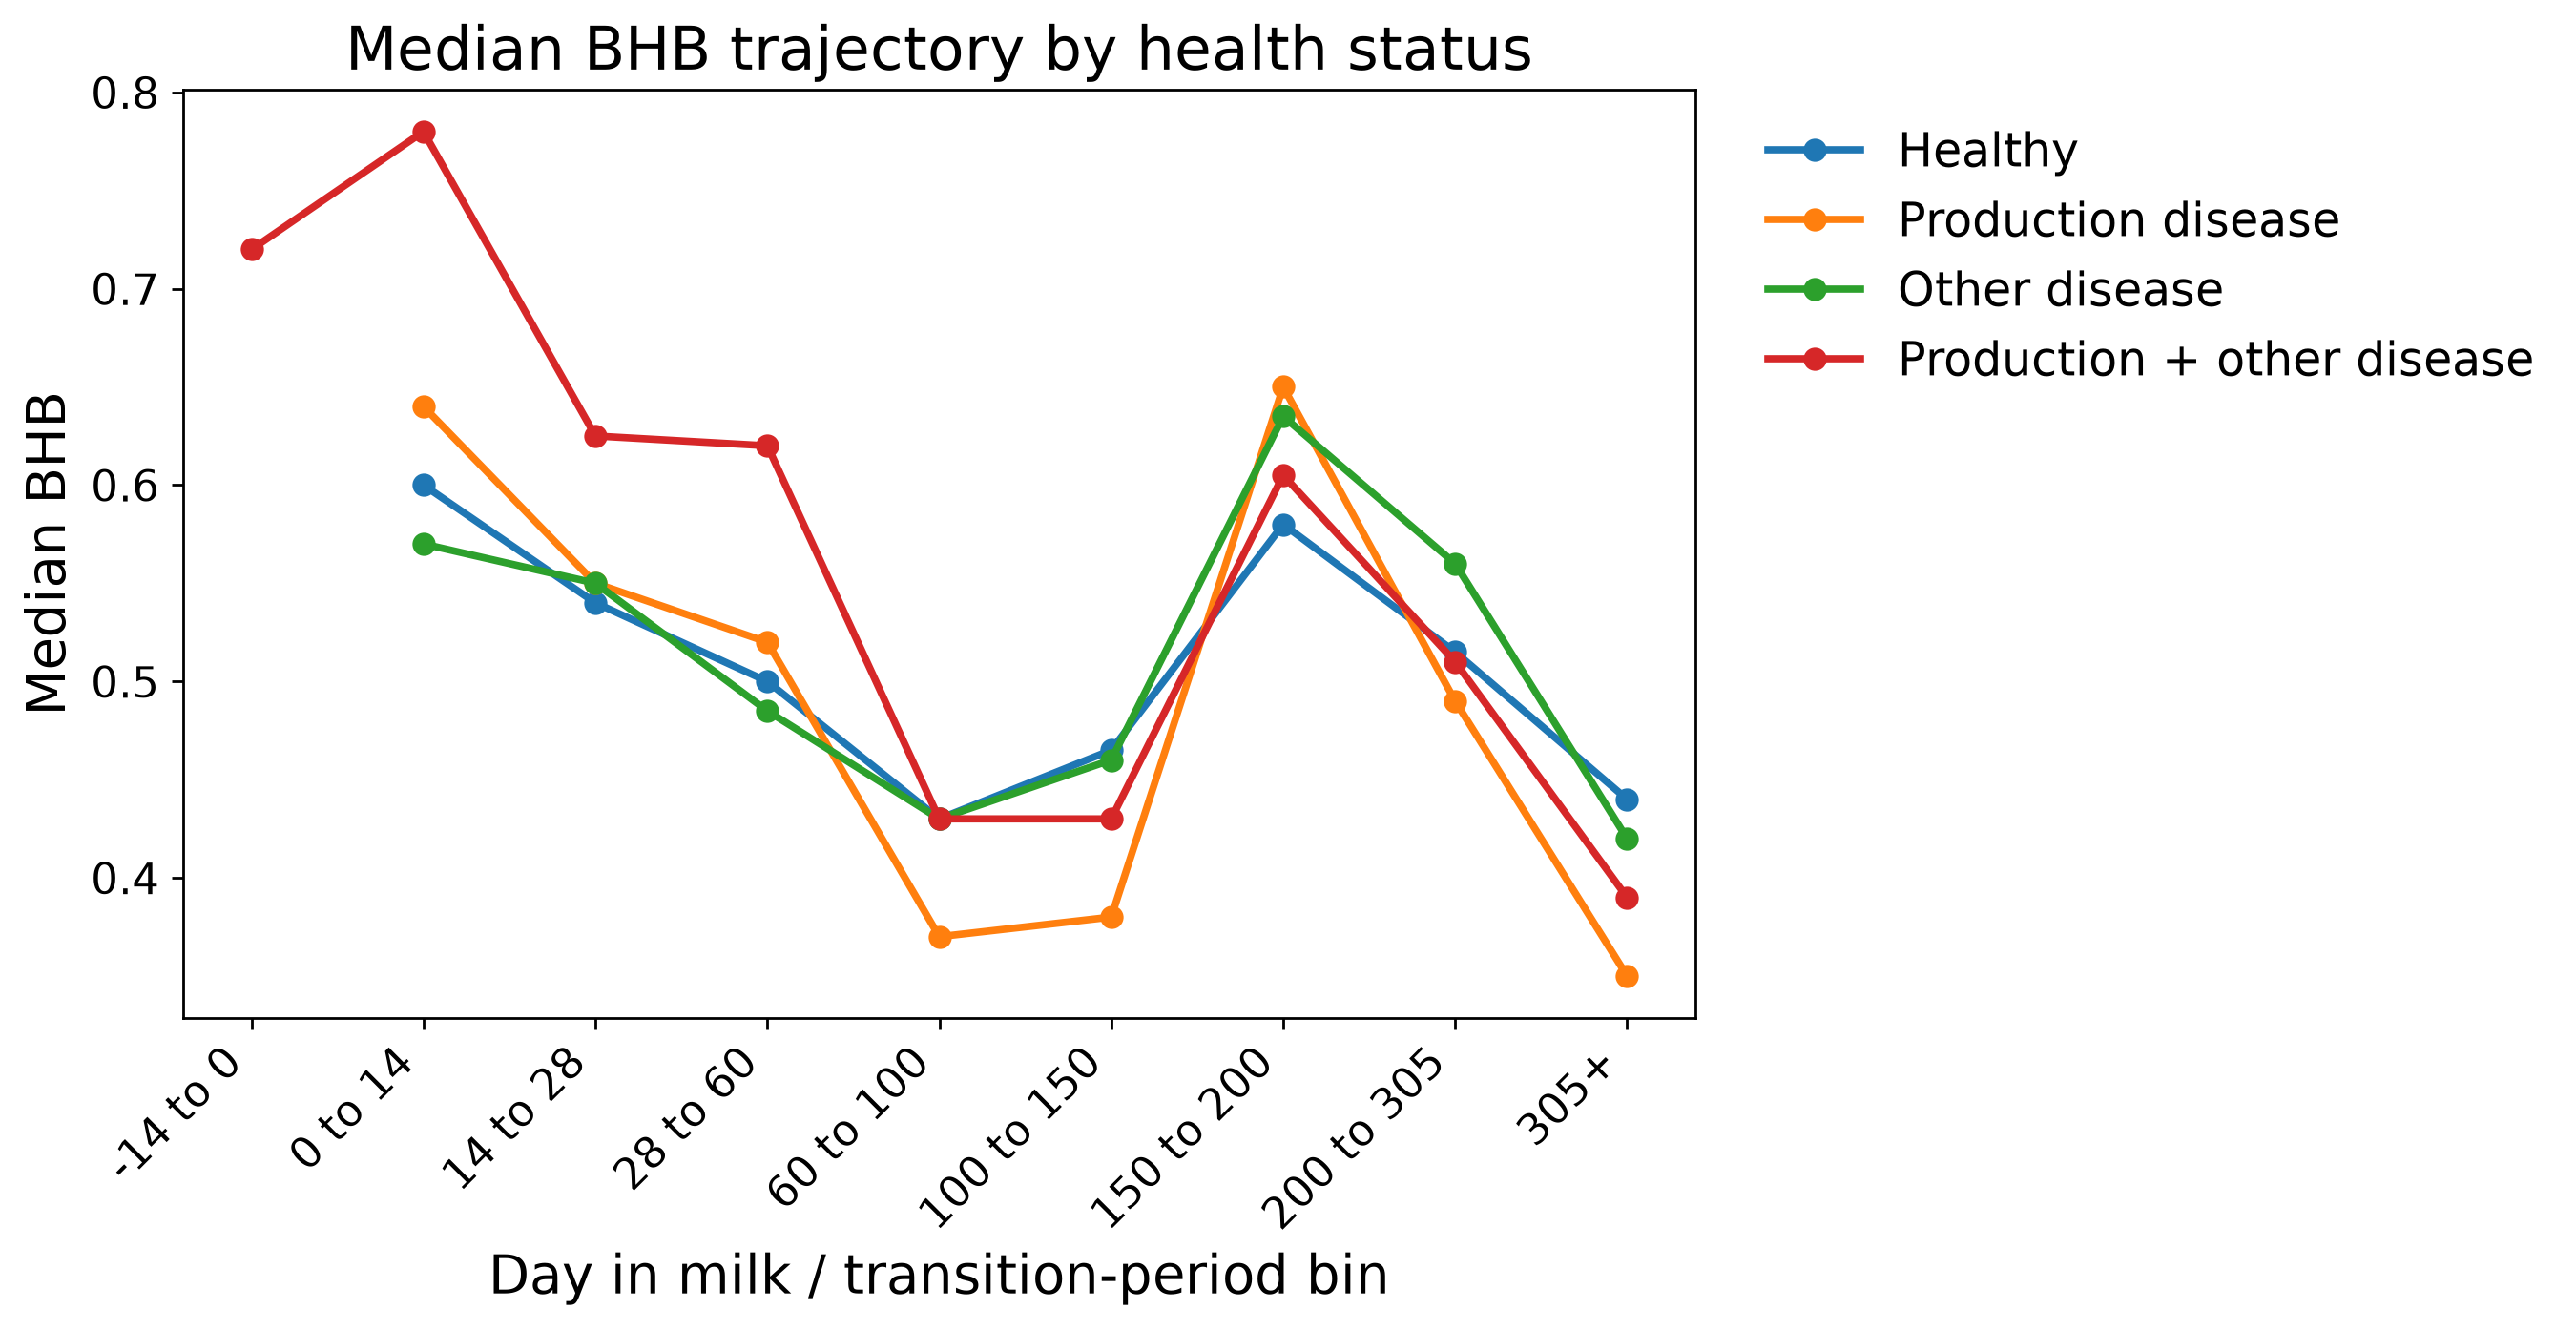

fig25_nefa_dim_trend_by_health_status.png


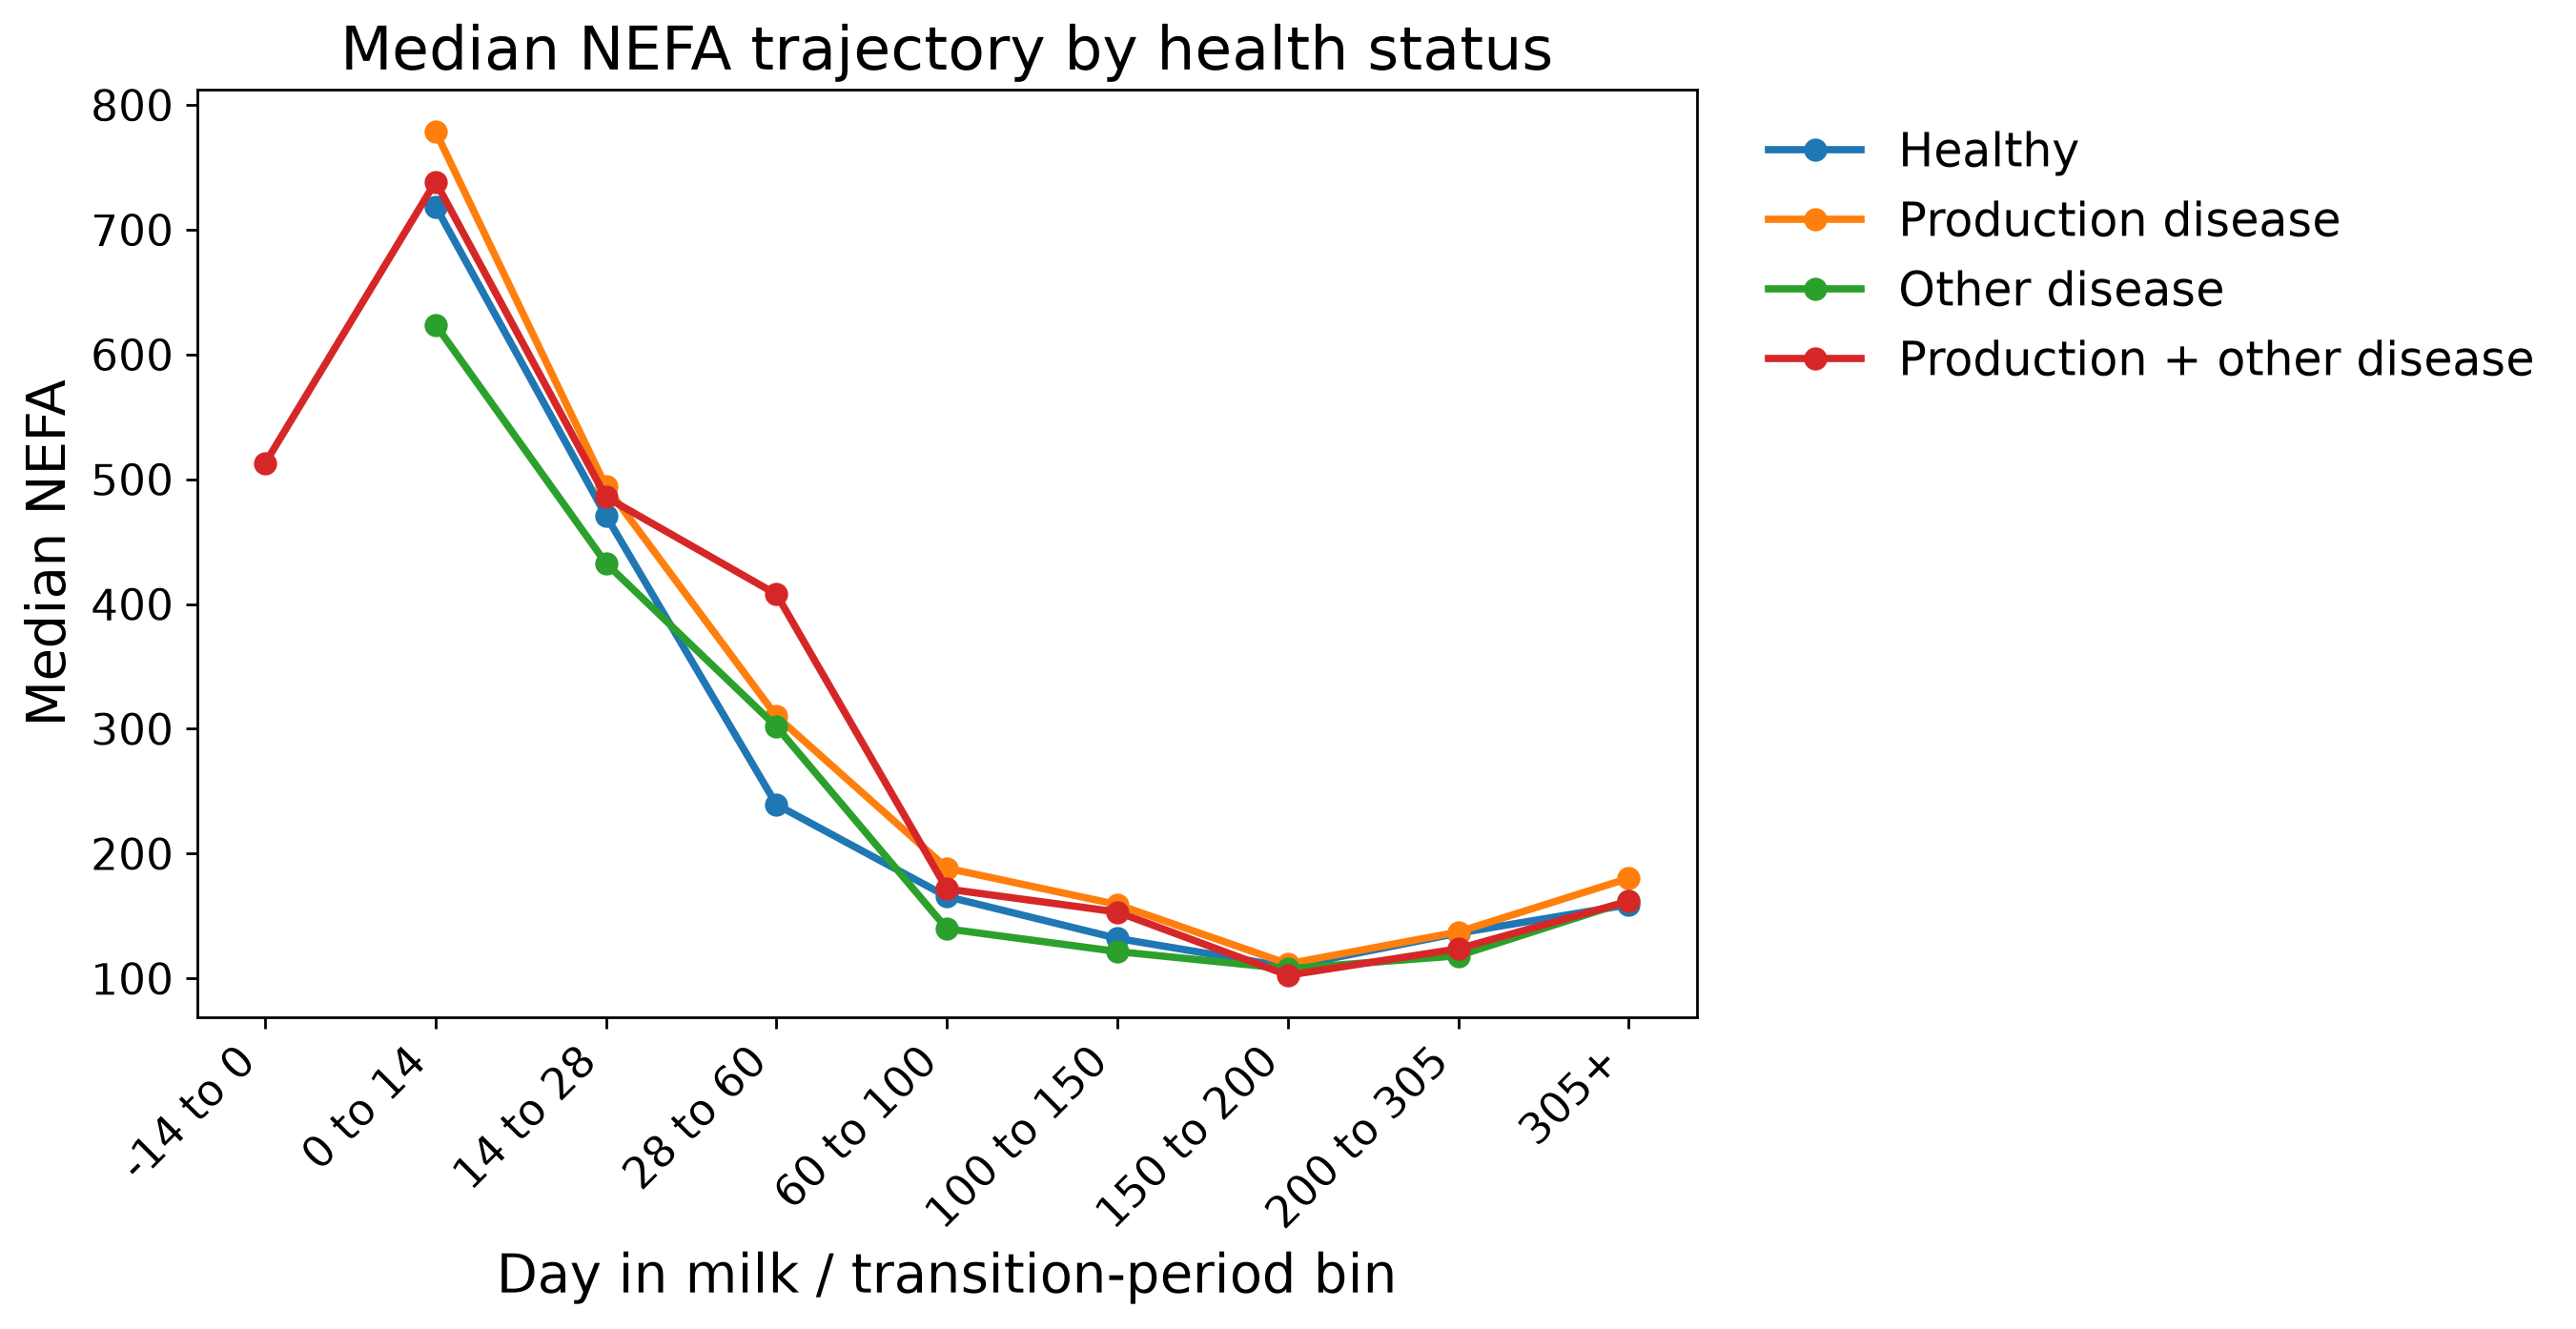

fig27_biomarker_availability_by_health_status.png


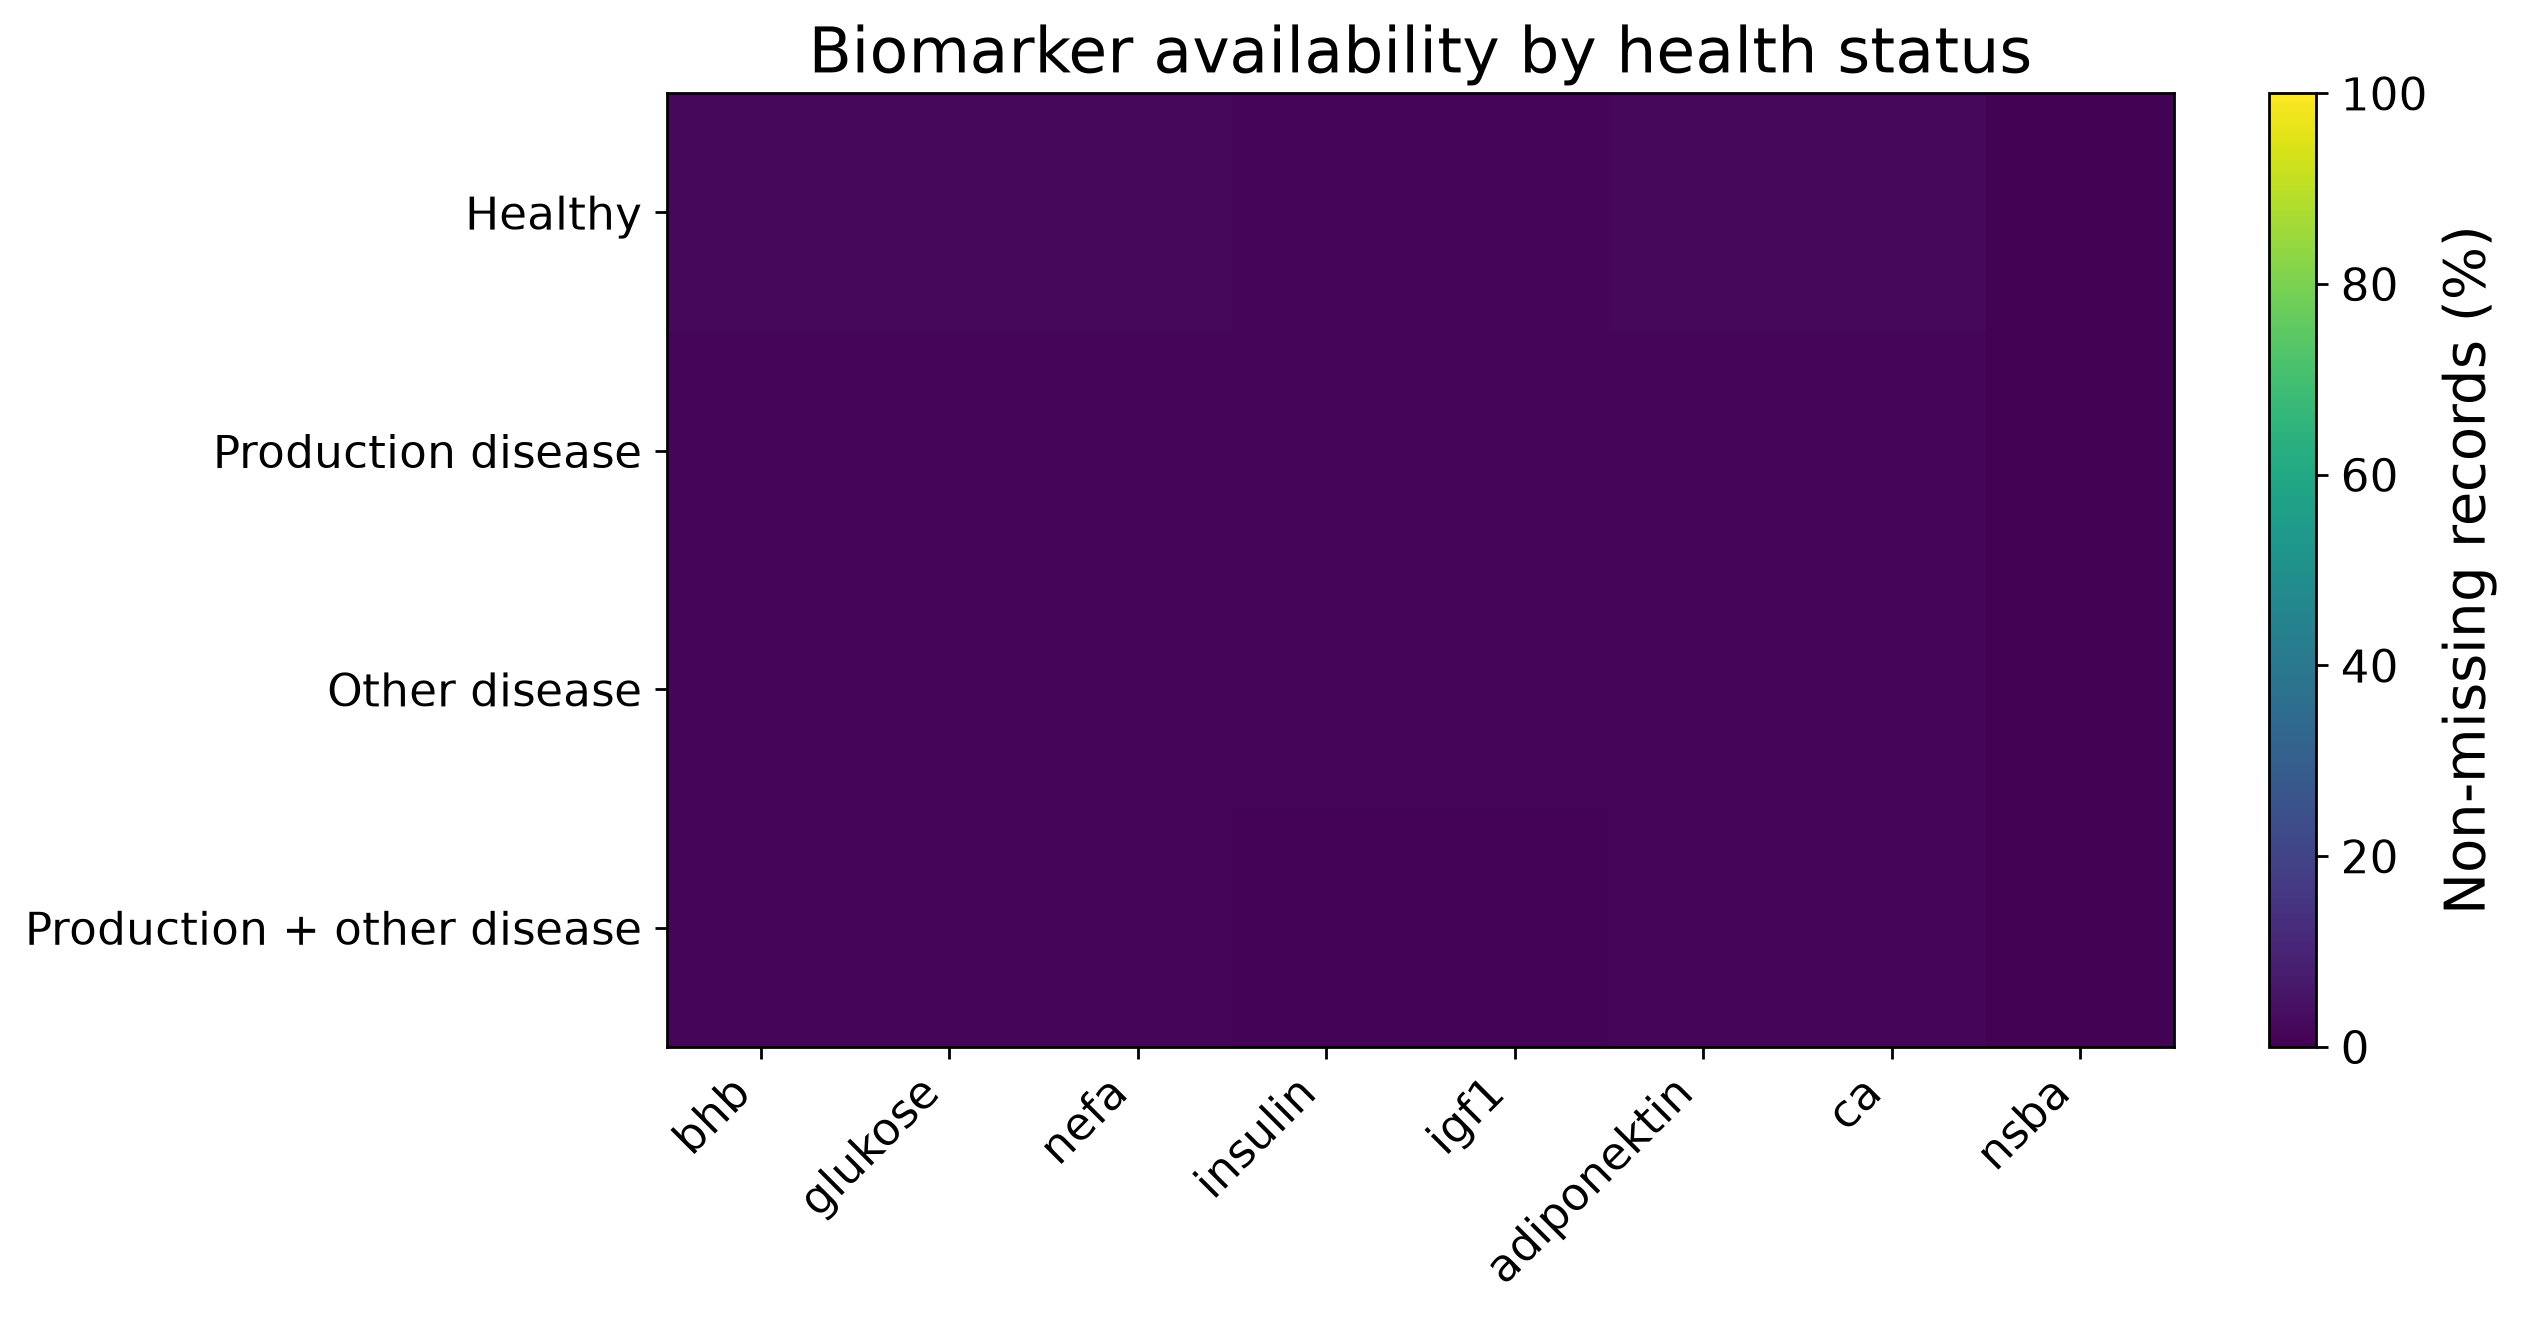

fig28_standardized_biomarker_profile_by_health_status.png


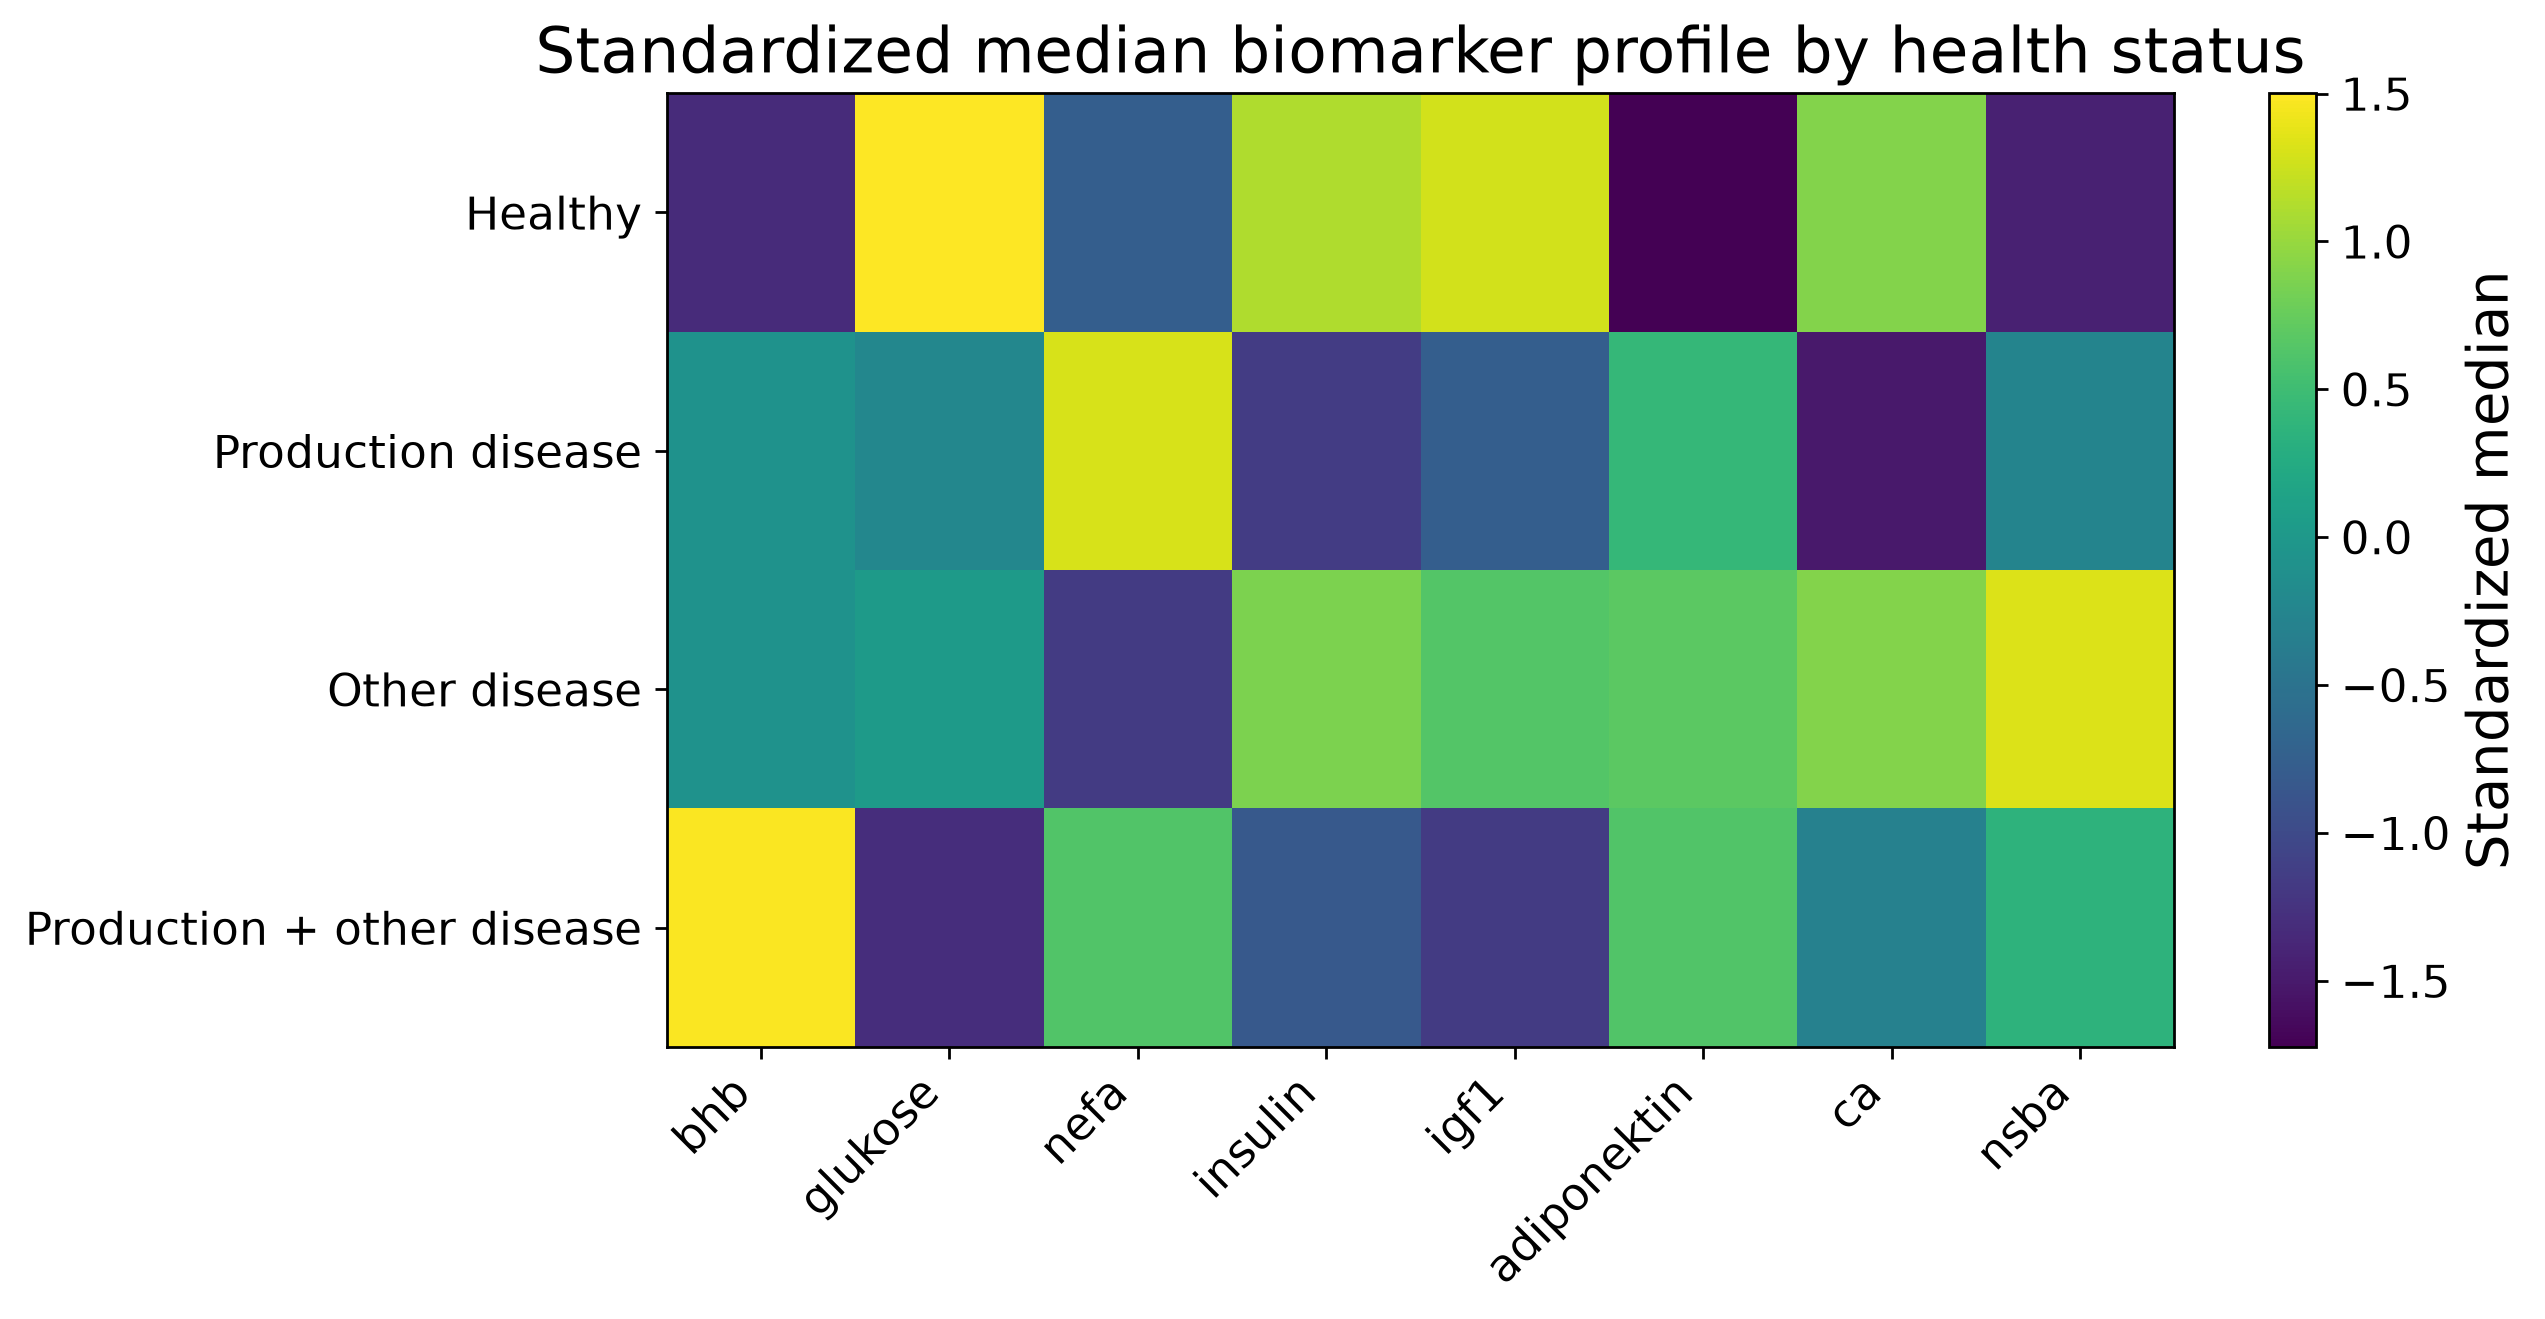

fig29_missingness_by_measurement_block.png


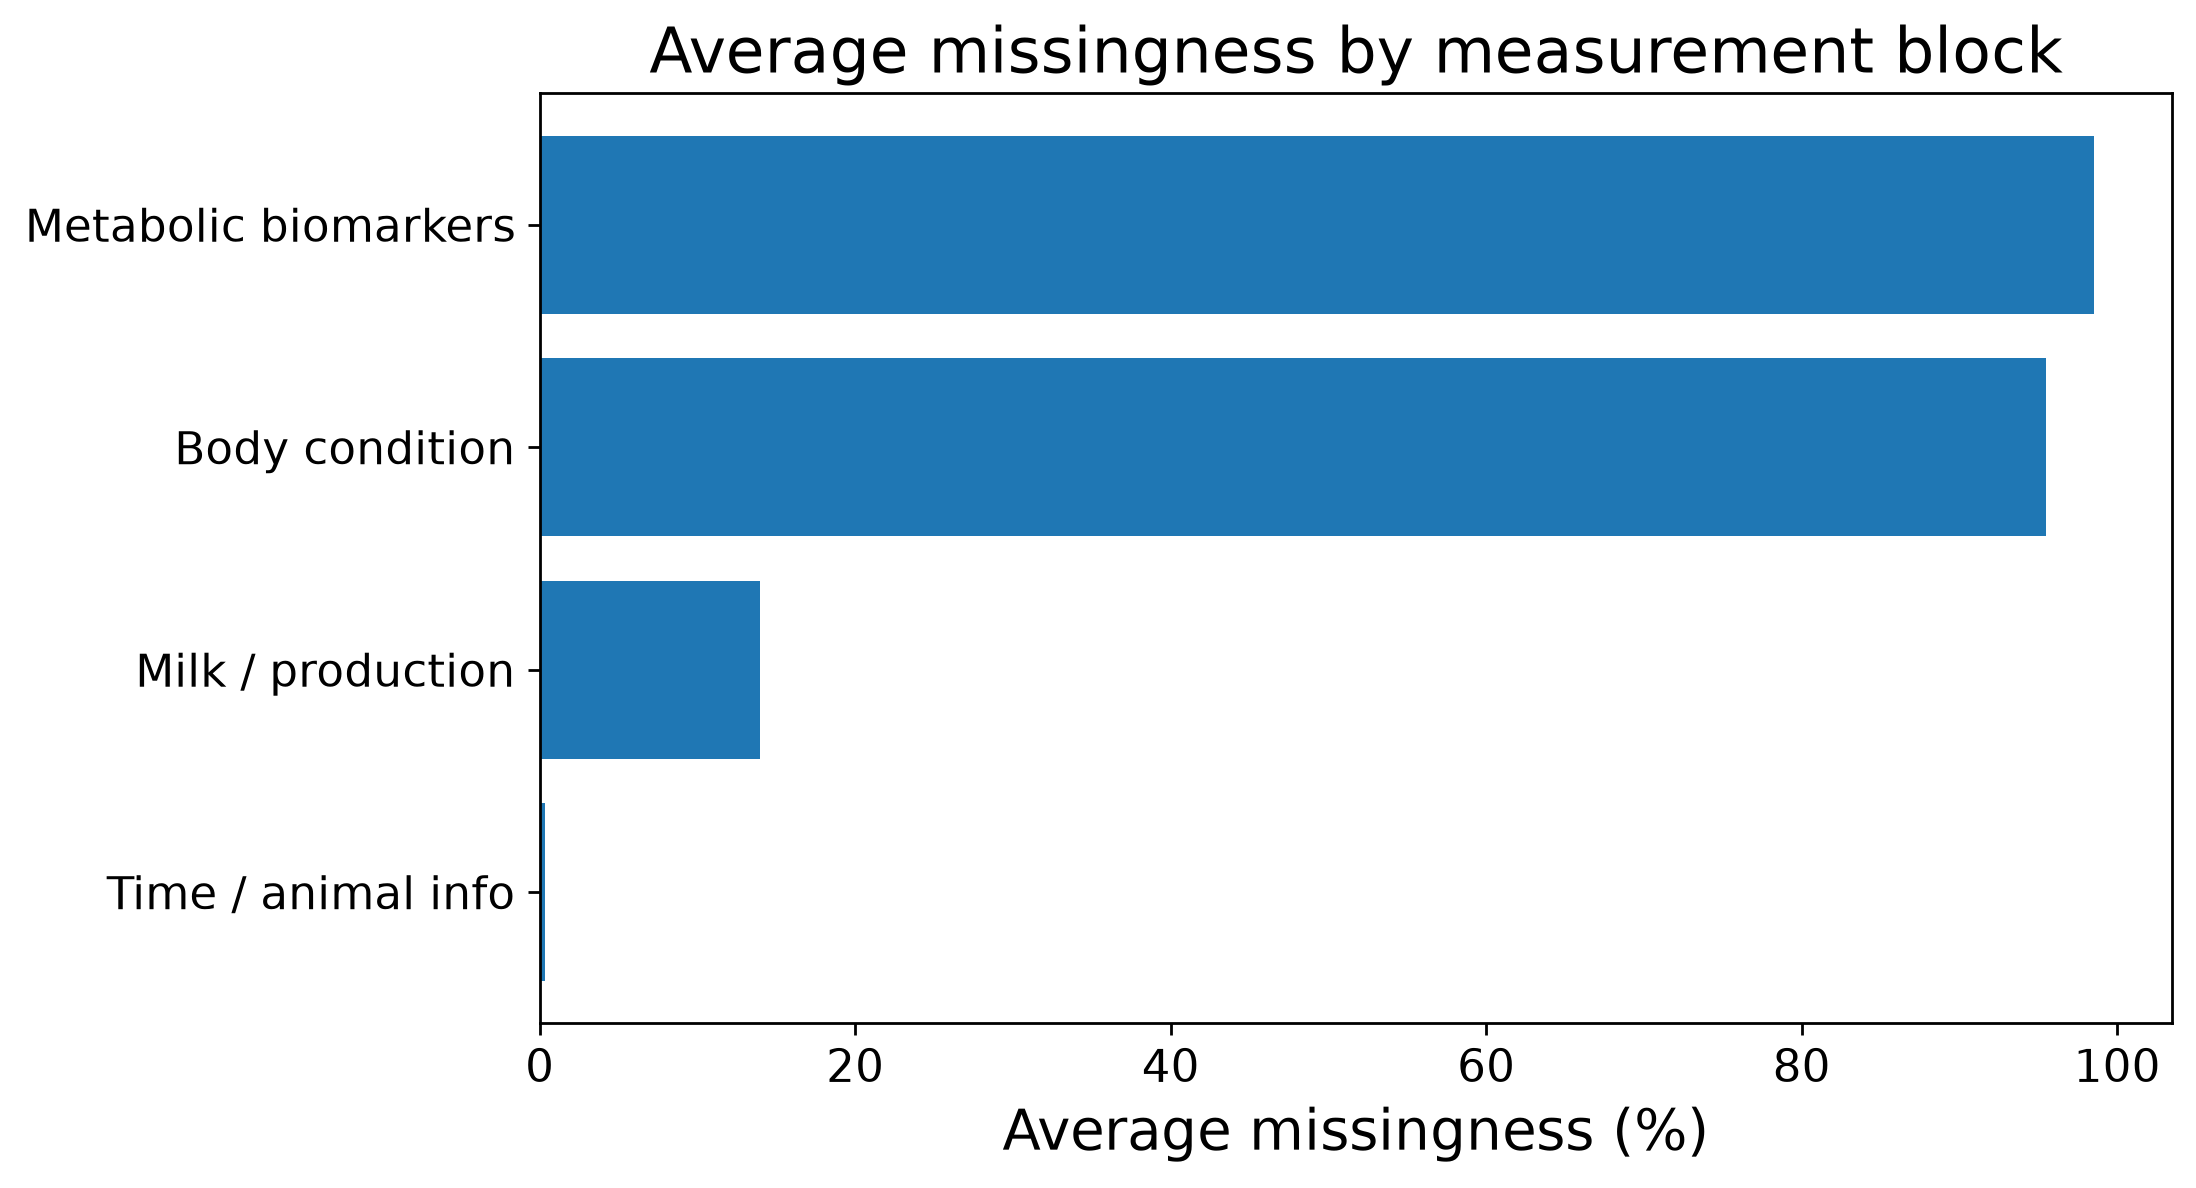

In [16]:
selected_figures = [
    "fig02_health_status_lactation_episodes.png",
    "fig06_records_over_time.png",
    "fig07_missingness_top20.png",
    "fig17_health_status_by_farm_percent.png",
    "fig18_health_status_by_breed_percent.png",
    "fig19_health_status_by_lactation_percent.png",
    "fig20_production_disease_rate_by_farm.png",
    "fig22_monthly_health_status_coverage.png",
    "fig23_milk_yield_dim_trend_by_health_status.png",
    "fig24_bhb_dim_trend_by_health_status.png",
    "fig25_nefa_dim_trend_by_health_status.png",
    "fig27_biomarker_availability_by_health_status.png",
    "fig28_standardized_biomarker_profile_by_health_status.png",
    "fig29_missingness_by_measurement_block.png",
]

from IPython.display import Image, display

for fig_name in selected_figures:
    fig_path = FIGURES_DIR / fig_name
    if fig_path.exists():
        print(fig_name)
        display(Image(filename=str(fig_path)))
    else:
        print("Missing:", fig_name)

In [13]:
eda.write_auto_numbers(tables, PRESENTATION_DIR)
eda.write_markdown_summary(tables, REPORTS_DIR)

print("Updated:")
print("- presentation/auto_numbers.tex")
print("- outputs/eda/reports/eda_summary.md")

Updated:
- presentation/auto_numbers.tex
- outputs/eda/reports/eda_summary.md
